# Bayes Factor to quantify the heterogeneity

This notebook simulates four 500-cell datasets with the same mean contact rate ($\mu_\lambda = 4.0$) and different combinations of Gamma heterogeneity ($\sigma_\lambda$) and zero inflation ($\phi_0$). For each synthetic dataset, it fits four Bayesian count models with SMC and computes pairwise Bayes factors. 

Within this framework, the Bayes factor allows us to identify the model that best describes the data and to quantify evidence for heterogeneity and zero inflation in the simulated cell population.

In [33]:
from __future__ import annotations

import os
import sys
from itertools import combinations
from pathlib import Path
from typing import Any, Dict, Optional, Sequence, Tuple


os.environ.setdefault("PYTENSOR_FLAGS", "optimizer_excluding=fusion")
os.environ.setdefault("HDF5_USE_FILE_LOCKING", "FALSE")
os.environ.setdefault("MPLCONFIGDIR", "/tmp/matplotlib")
os.environ.setdefault("XDG_CACHE_HOME", "/tmp/.cache")

import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from tqdm.auto import tqdm

PROJECT_ROOT = next(
    p for p in [Path.cwd(), *Path.cwd().parents]
    if (p / "section_1" / "src" / "inference.py").exists()
)
sys.path.insert(0, str(PROJECT_ROOT))

from section_1.src import inference as cih
from section_1.src import simulator as sim

import scienceplots
plt.style.use(["science"])

In [34]:
N_CELL = 500
T_OBS = 1.0
GT_MU_LAMBDA = 4.0
GT_SIGMA_LAMBDA = 3.0
GT_P_ZERO = 0.2
BASE_SEED = 2026

# Set FORCE_RERUN=True when you want to overwrite cached simulations/posteriors.
FORCE_RERUN = True

# SMC settings. 
CHAINS = 8
SMC_PARTICLES = 10000
SMC_CORES = 0
LAMBDA_PRIOR_BOUNDS = (0.0, 2.0)
STD_PRIOR_FACTOR = 5.0
SMC_THRESHOLD = 0.5
SMC_CORRELATION_THRESHOLD = 0.01

RESULT_ROOT = PROJECT_ROOT / "section_1" / "results" / "part_2"
FIGURE_ROOT = PROJECT_ROOT / "section_1" / "figures" / "part_2"
RESULT_ROOT.mkdir(parents=True, exist_ok=True)
FIGURE_ROOT.mkdir(parents=True, exist_ok=True)

print("RESULT_ROOT (results will be stored in):", RESULT_ROOT)
print("FIGURE_ROOT (figures will be stored in):", FIGURE_ROOT)

RESULT_ROOT (results will be stored in): /Users/marsian/PhD_LifeSciRes/Orca/section_1/results/part_2
FIGURE_ROOT (figures will be stored in): /Users/marsian/PhD_LifeSciRes/Orca/section_1/figures/part_2


## Scenario and Model Configurations

The simulation parameters and general inference settings are defined here.

Number of cells in each of the synthetic datasets: 500 cells

In the iteration below, we generate four synthetic datasets by looping over the following parameter settings:

| Scenario | `mu_lambda` | `sigma_lambda` | `p_zero` |
|---|---:|---:|---:|
| No1  | 4.0 | 3.0 | 0.2 |
| No2  | 4.0 | 0.0 | 0.2 |
| No3  | 4.0 | 3.0 | 0.0 |
| No4  | 4.0 | 0.0 | 0.0 |

In [35]:
SCENARIOS = [
    {
        "number": "No1",
        "name": "scenario-1",
        "label": "No1: sigma=3, p0=0.2",
        "mu_lambda": GT_MU_LAMBDA,
        "sigma_lambda": GT_SIGMA_LAMBDA,
        "p_zero": GT_P_ZERO,
        "seed": BASE_SEED + 1,
    },
    {
        "number": "No2",
        "name": "scenario-2",
        "label": "No2: sigma=0, p0=0.2",
        "mu_lambda": GT_MU_LAMBDA,
        "sigma_lambda": 0.0,
        "p_zero": GT_P_ZERO,
        "seed": BASE_SEED + 2,
    },
    {
        "number": "No3",
        "name": "scenario-3",
        "label": "No3: sigma=3, p0=0",
        "mu_lambda": GT_MU_LAMBDA,
        "sigma_lambda": GT_SIGMA_LAMBDA,
        "p_zero": 0.0,
        "seed": BASE_SEED + 3,
    },
    {
        "number": "No4",
        "name": "scenario-4",
        "label": "No4: sigma=0, p0=0",
        "mu_lambda": GT_MU_LAMBDA,
        "sigma_lambda": 0.0,
        "p_zero": 0.0,
        "seed": BASE_SEED + 4,
    },
]

MODEL_ORDER = ["homo", "Z2P", "Dis2P", "hetero3"]
MODEL_DISPLAY = {
    "homo": "homo",
    "Z2P": "ZI",
    "Dis2P": "$\Gamma$",
    "hetero3": "ZI $\Gamma$",
}
MODEL_PARAMS = {
    "homo": ["lambda"],
    "Z2P": ["lambda", "p_zero"],
    "Dis2P": ["mu_lambda", "sigma_lambda"],
    "hetero3": ["mu_lambda", "sigma_lambda", "p_zero"],
}
COMMON_PARAMS = ["mu_lambda", "sigma_lambda", "p_zero"]
PARAM_DISPLAY = {
    "lambda": r"$\lambda$",
    "mu_lambda": r"$\mu_{\lambda}$",
    "sigma_lambda": r"$\sigma_{\lambda}$",
    "p_zero": r"$\phi_0$",
}

INFERENCE_FUNCTIONS = {
    "homo": cih.inference_homo,
    "Z2P": cih.inference_Z2P,
    "Dis2P": cih.inference_Dis2P,
    "hetero3": cih.inference_hetero3,
}


def safe_slug(text: str) -> str:
    return "".join(ch if ch.isalnum() else "_" for ch in str(text)).strip("_")


def scenario_dir(scenario: dict[str, Any]) -> Path:
    return RESULT_ROOT / f"{scenario['number']}_{safe_slug(scenario['name'])}"


def ground_truth_for_model(scenario: dict[str, Any], model_name: str) -> dict[str, float]:
    mu = float(scenario["mu_lambda"])
    sigma = float(scenario["sigma_lambda"])
    p0 = float(scenario["p_zero"])
    if model_name == "homo":
        return {"lambda": mu}
    if model_name == "Z2P":
        return {"lambda": mu, "p_zero": p0}
    if model_name == "Dis2P":
        return {"mu_lambda": mu, "sigma_lambda": sigma}
    if model_name == "hetero3":
        return {"mu_lambda": mu, "sigma_lambda": sigma, "p_zero": p0}
    return {}


pd.DataFrame(SCENARIOS)

<>:44: SyntaxWarning: invalid escape sequence '\G'
<>:45: SyntaxWarning: invalid escape sequence '\G'
<>:44: SyntaxWarning: invalid escape sequence '\G'
<>:45: SyntaxWarning: invalid escape sequence '\G'
/var/folders/rr/16wv6ts1785fz6_2qhr5bc2m0000gn/T/ipykernel_80444/4208080854.py:44: SyntaxWarning: invalid escape sequence '\G'
  "Dis2P": "$\Gamma$",
/var/folders/rr/16wv6ts1785fz6_2qhr5bc2m0000gn/T/ipykernel_80444/4208080854.py:45: SyntaxWarning: invalid escape sequence '\G'
  "hetero3": "ZI $\Gamma$",


,number,name,label,mu_lambda,sigma_lambda,p_zero,seed
0,No1,scenario-1,"No1: sigma=3, p0=0.2",4.0,3.0,0.2,2027
1,No2,scenario-2,"No2: sigma=0, p0=0.2",4.0,0.0,0.2,2028
2,No3,scenario-3,"No3: sigma=3, p0=0",4.0,3.0,0.0,2029
3,No4,scenario-4,"No4: sigma=0, p0=0",4.0,0.0,0.0,2030


## Run simulations and Bayesian inference

In [36]:
def save_idata(idata: az.InferenceData, out_path: Path) -> None:
    out_path.parent.mkdir(parents=True, exist_ok=True)
    tmp_path = out_path.with_name(f".{out_path.stem}.{os.getpid()}.tmp{out_path.suffix}")
    if tmp_path.exists():
        tmp_path.unlink()
    az.to_netcdf(idata, str(tmp_path))
    tmp_path.replace(out_path)


def load_or_simulate(scenario: dict[str, Any]) -> dict[str, Any]:
    out_dir = scenario_dir(scenario)
    out_dir.mkdir(parents=True, exist_ok=True)
    sim_path = out_dir / "simulation_data.npz"
    config_path = out_dir / "simulation_config.csv"

    if sim_path.exists() and not FORCE_RERUN:
        loaded = np.load(sim_path)
        return {key: loaded[key] for key in loaded.files}

    sim_data = sim.simulate_Population(
        n_cells=N_CELL,
        T=T_OBS,
        mode="heterogeneous",
        mu_lambda=float(scenario["mu_lambda"]),
        sd_lambda=float(scenario["sigma_lambda"]),
        p0_lambda=float(scenario["p_zero"]),
        Dist_mode="gamma",
        seed=int(scenario["seed"]),
    )
    np.savez_compressed(sim_path, **sim_data)
    pd.DataFrame([scenario | {"n_cell": N_CELL, "T": T_OBS}]).to_csv(config_path, index=False)
    return sim_data


def run_or_load_inference(
    scenario: dict[str, Any],
    sim_data: dict[str, Any],
    model_name: str,
    model_index: int,
) -> az.InferenceData:
    out_dir = scenario_dir(scenario)
    posterior_path = out_dir / f"posterior_{model_name}_smc.nc"
    summary_path = out_dir / f"posterior_summary_{model_name}_smc.csv"
    logml_path = out_dir / f"log_marginal_likelihood_{model_name}_smc.csv"

    if posterior_path.exists() and logml_path.exists() and not FORCE_RERUN:
        return az.from_netcdf(str(posterior_path))

    counts = np.asarray(sim_data["n_events"], dtype=int)
    obs_time = float(sim_data["max_time"])
    fn = INFERENCE_FUNCTIONS[model_name]
    common_kwargs = dict(
        draws=SMC_PARTICLES,
        chains=CHAINS,
        cores=SMC_CORES,
        lambda_prior_bounds=LAMBDA_PRIOR_BOUNDS,
        random_seed=int(scenario["seed"]) + 1000 + model_index,
        threshold=SMC_THRESHOLD,
        correlation_threshold=SMC_CORRELATION_THRESHOLD,
    )
    if model_name in {"Z2P", "hetero3"}:
        common_kwargs["p_prior_bounds"] = (1.0, 1.0)
    if model_name in {"Dis2P", "hetero3"}:
        common_kwargs["std_prior_factor"] = STD_PRIOR_FACTOR

    print(f"Running {scenario['number']} {scenario['name']} / {model_name} ...")
    pack = fn(counts, obs_time, **common_kwargs)
    idata = pack["idata"]
    save_idata(idata, posterior_path)
    az.summary(idata).to_csv(summary_path)
    pd.DataFrame(
        [
            {
                "scenario": scenario["number"],
                "scenario_name": scenario["name"],
                "model": model_name,
                "logml": cih.smc_log_evidence(idata),
                "sampler": "smc",
                "chains": CHAINS,
                "smc_particles": SMC_PARTICLES,
            }
        ]
    ).to_csv(logml_path, index=False)
    return idata


def bayes_factor_pairs(logml_by_model: dict[str, float]) -> pd.DataFrame:
    rows = []
    for m1, m2 in combinations(MODEL_ORDER, 2):
        d = float(logml_by_model[m1] - logml_by_model[m2])
        rows.append(
            {
                "model_1": m1,
                "model_2": m2,
                "logml_1": float(logml_by_model[m1]),
                "logml_2": float(logml_by_model[m2]),
                "delta_logml": d,
                "log10_BF": d / np.log(10.0),
                "BF": float(np.exp(d)) if d < 709 else np.inf,
            }
        )
    return pd.DataFrame(rows).sort_values("delta_logml", ascending=False).reset_index(drop=True)


simulation_data: dict[str, dict[str, Any]] = {}
posterior_data: dict[tuple[str, str], az.InferenceData] = {}
logml_rows = []
bf_tables: dict[str, pd.DataFrame] = {}

for scenario in SCENARIOS:
    sim_data = load_or_simulate(scenario)
    simulation_data[scenario["number"]] = sim_data

    logml_by_model = {}
    for model_index, model_name in enumerate(MODEL_ORDER):
        idata = run_or_load_inference(scenario, sim_data, model_name, model_index)
        posterior_data[(scenario["number"], model_name)] = idata
        logml = cih.smc_log_evidence(idata)
        logml_by_model[model_name] = logml
        logml_rows.append(
            {
                "scenario": scenario["number"],
                "scenario_name": scenario["name"],
                "model": model_name,
                "logml": logml,
            }
        )

    bf = bayes_factor_pairs(logml_by_model)
    bf_tables[scenario["number"]] = bf
    bf.to_csv(scenario_dir(scenario) / "bayes_factors_pairs_smc.csv", index=False)

logml_df = pd.DataFrame(logml_rows)
logml_df.to_csv(RESULT_ROOT / "log_marginal_likelihoods_all_scenarios_smc.csv", index=False)
logml_df.sort_values(["scenario", "logml"], ascending=[True, False])

Initializing SMC sampler...
Sampling 8 chains in 8 jobs


Running No1 scenario-1 / homo ...


Output()

         mean     sd  hdi_2.5%  hdi_97.5%  mcse_mean  mcse_sd  ess_bulk  \
eta     0.553  0.010     0.533      0.573        0.0      0.0   80638.0   
lambda  3.576  0.085     3.412      3.743        0.0      0.0   80638.0   

        ess_tail  r_hat  
eta      79731.0    1.0  
lambda   79731.0    1.0  


Initializing SMC sampler...


...

               mean     sd  hdi_2.5%  hdi_97.5%  mcse_mean  mcse_sd  ess_bulk  \
eta           0.597  0.010     0.578      0.617      0.000    0.000   76955.0   
sigma_lambda  0.395  0.224     0.001      0.771      0.001    0.001   19240.0   
mu_lambda     3.959  0.091     3.784      4.141      0.000    0.000   76955.0   

              ess_tail  r_hat  
eta            71064.0    1.0  
sigma_lambda    7577.0    1.0  
mu_lambda      71064.0    1.0  
Running No4 scenario-4 / hetero3 ...


Sampling 8 chains in 8 jobs


Output()

               mean     sd  hdi_2.5%  hdi_97.5%  mcse_mean  mcse_sd  ess_bulk  \
eta           0.599  0.010     0.579      0.618      0.000      0.0   80169.0   
sigma_lambda  0.379  0.215     0.019      0.754      0.001      0.0   74083.0   
p_zero        0.005  0.004     0.000      0.013      0.000      0.0   79109.0   
mu_lambda     3.969  0.092     3.787      4.146      0.000      0.0   80169.0   

              ess_tail  r_hat  
eta            79905.0    1.0  
sigma_lambda   65572.0    1.0  
p_zero         75710.0    1.0  
mu_lambda      79905.0    1.0  


,scenario,scenario_name,model,logml
3,No1,scenario-1,hetero3,-1200.723774
2,No1,scenario-1,Dis2P,-1207.422953
1,No1,scenario-1,Z2P,-1342.040299
0,No1,scenario-1,homo,-1601.451348
5,No2,scenario-2,Z2P,-1055.450908
7,No2,scenario-2,hetero3,-1057.924797
6,No2,scenario-2,Dis2P,-1128.205284
4,No2,scenario-2,homo,-1196.185883
10,No3,scenario-3,Dis2P,-1230.760498
11,No3,scenario-3,hetero3,-1234.256363


## Plotting

**posteriors**

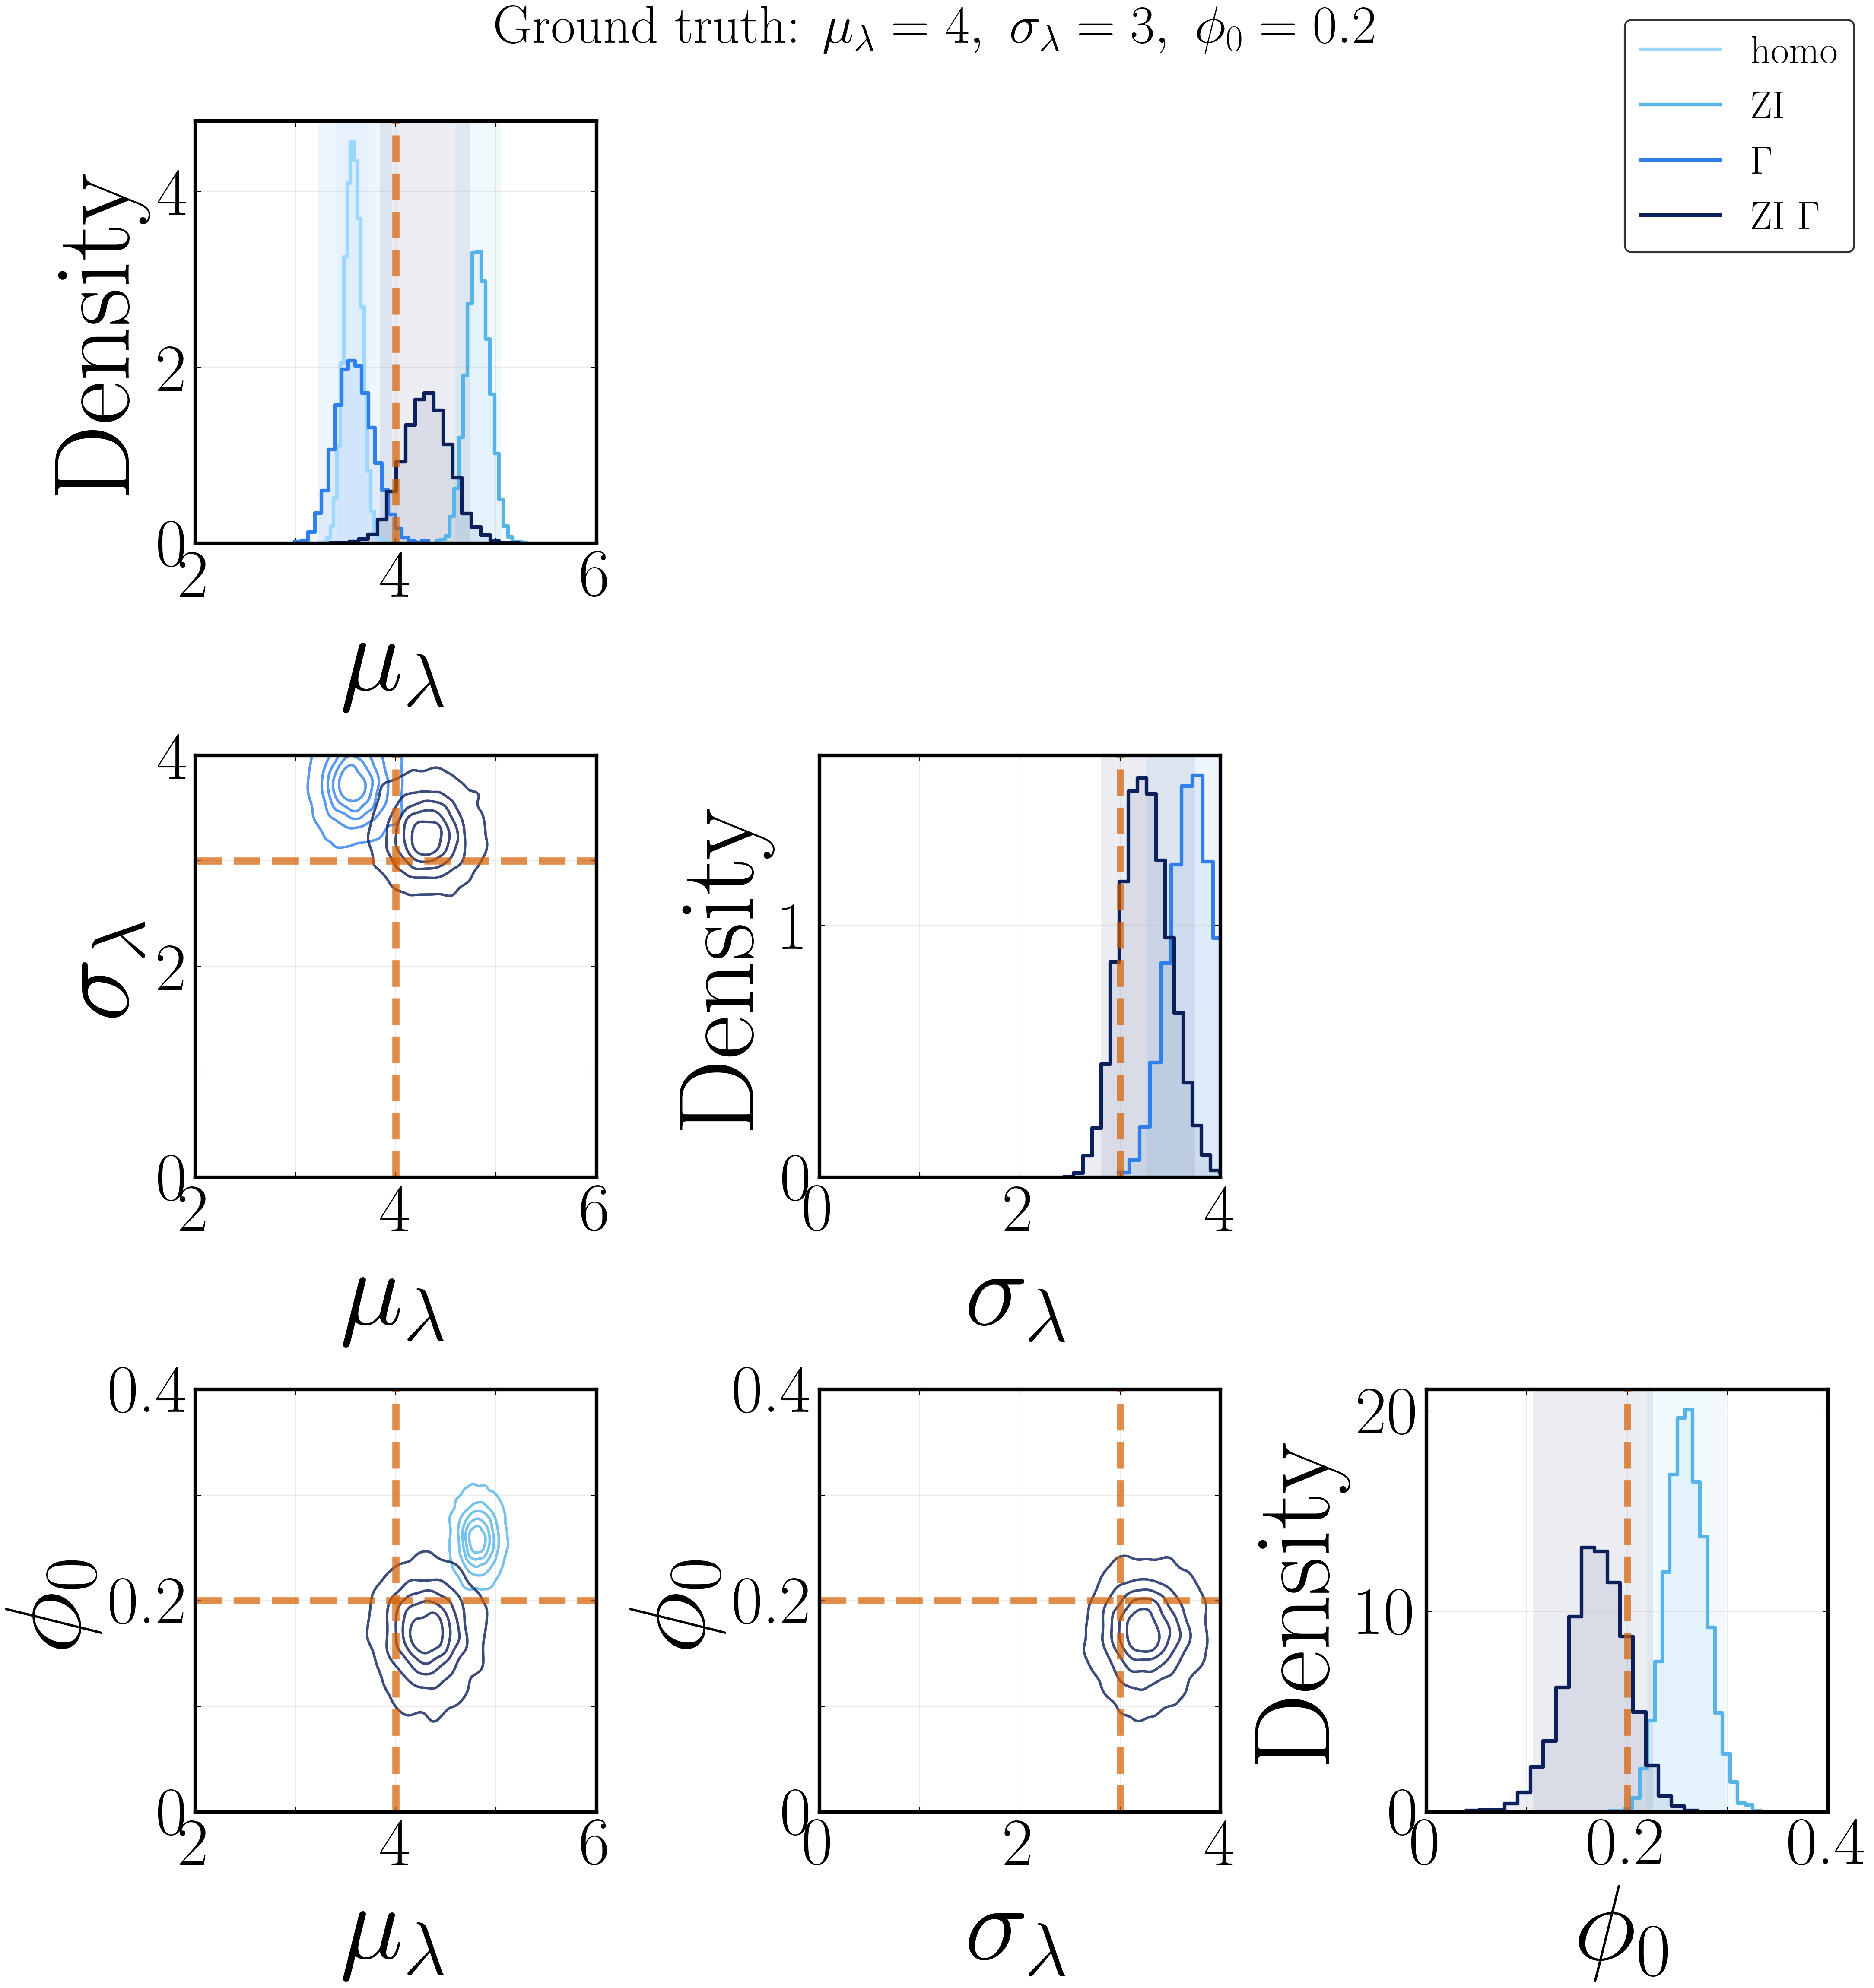

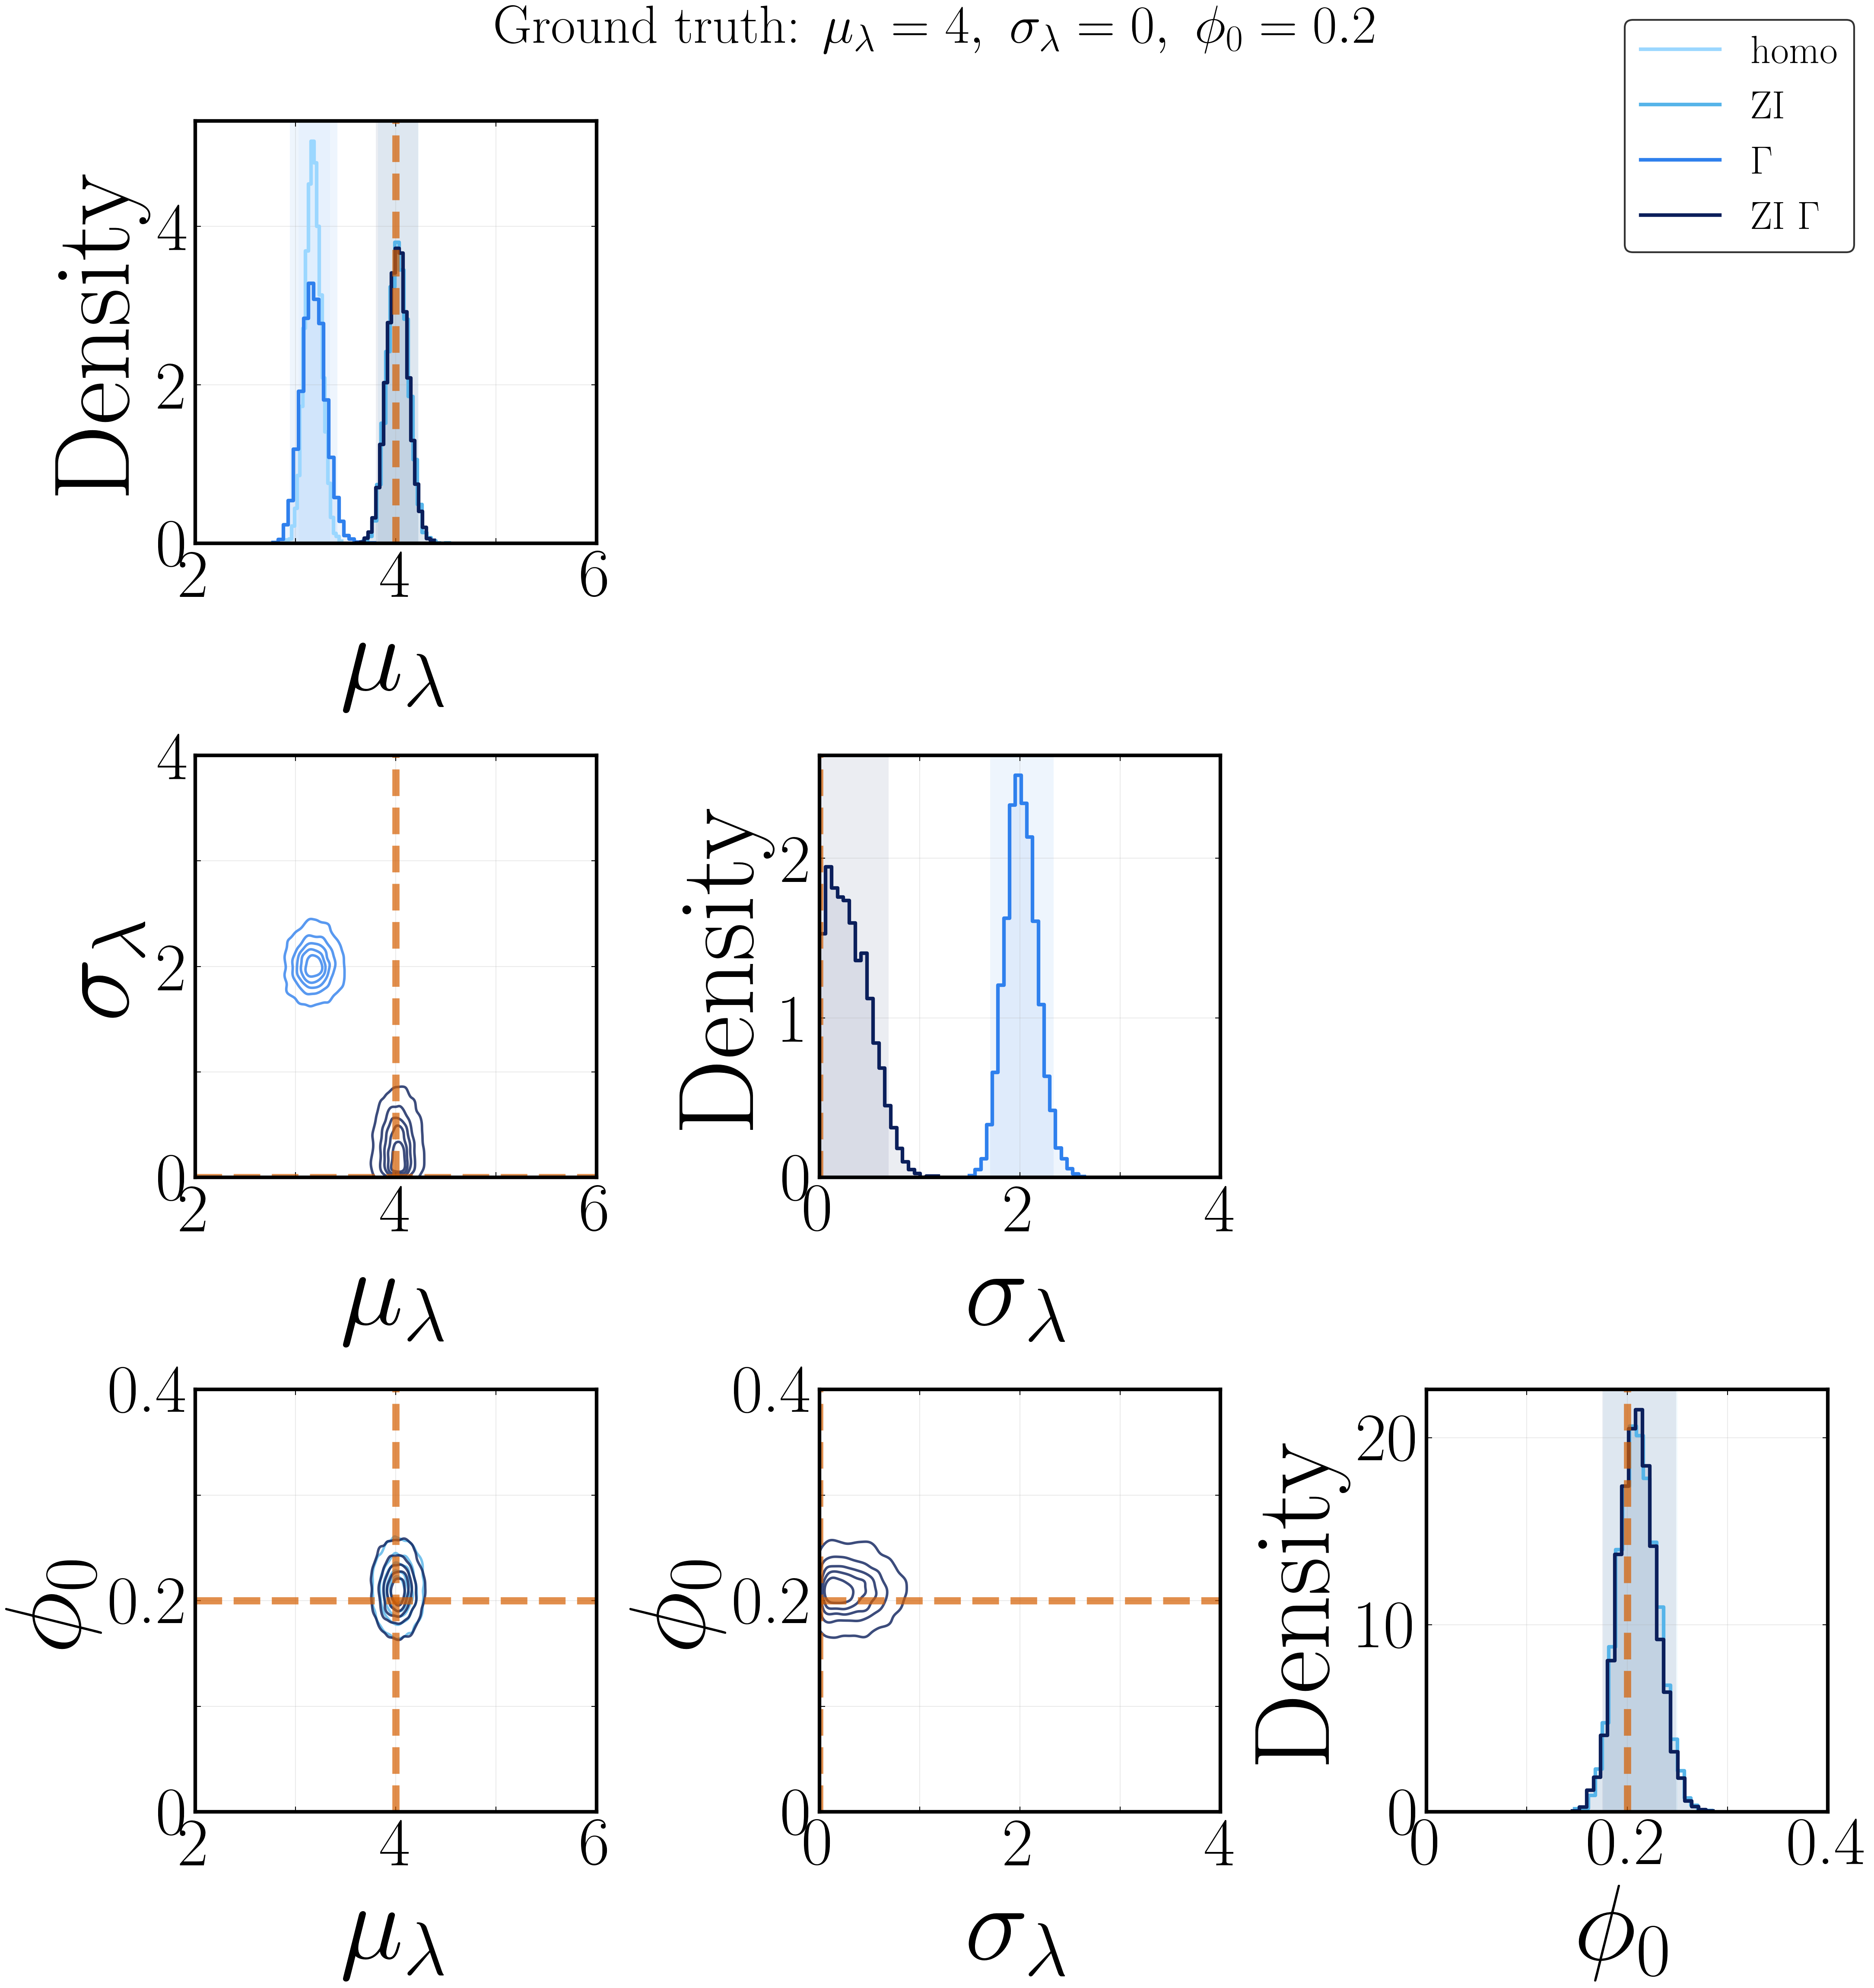

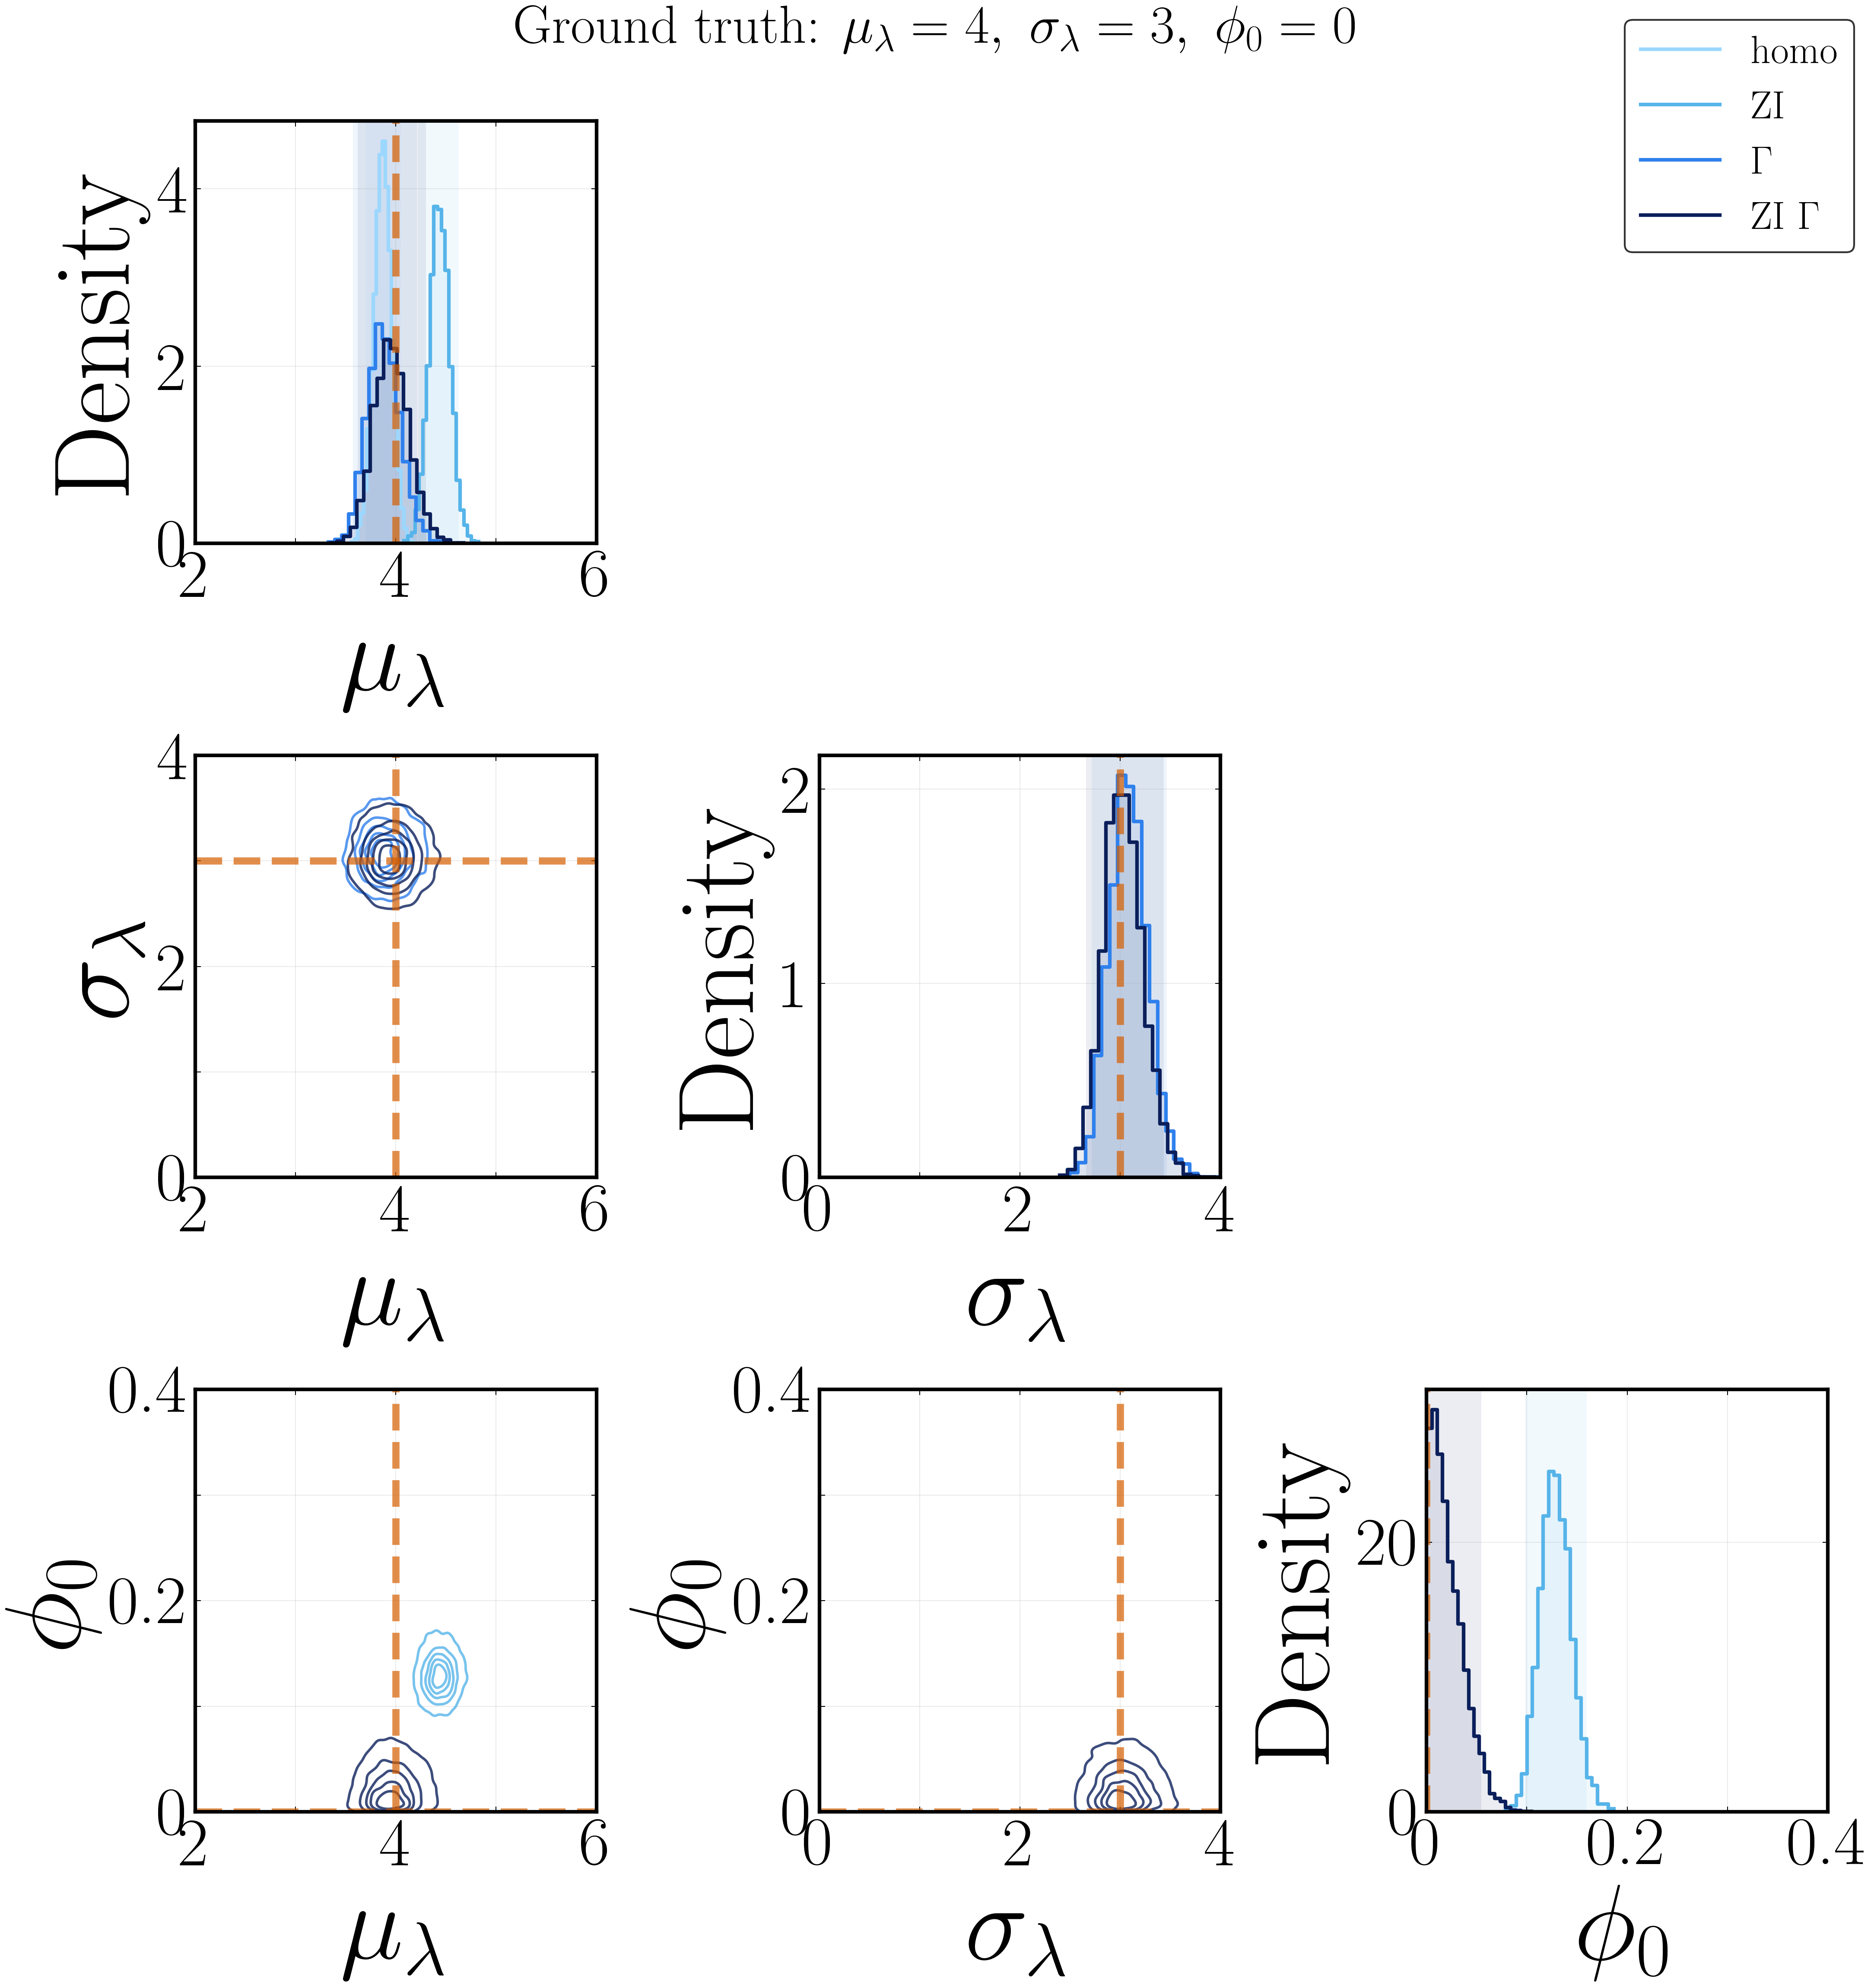

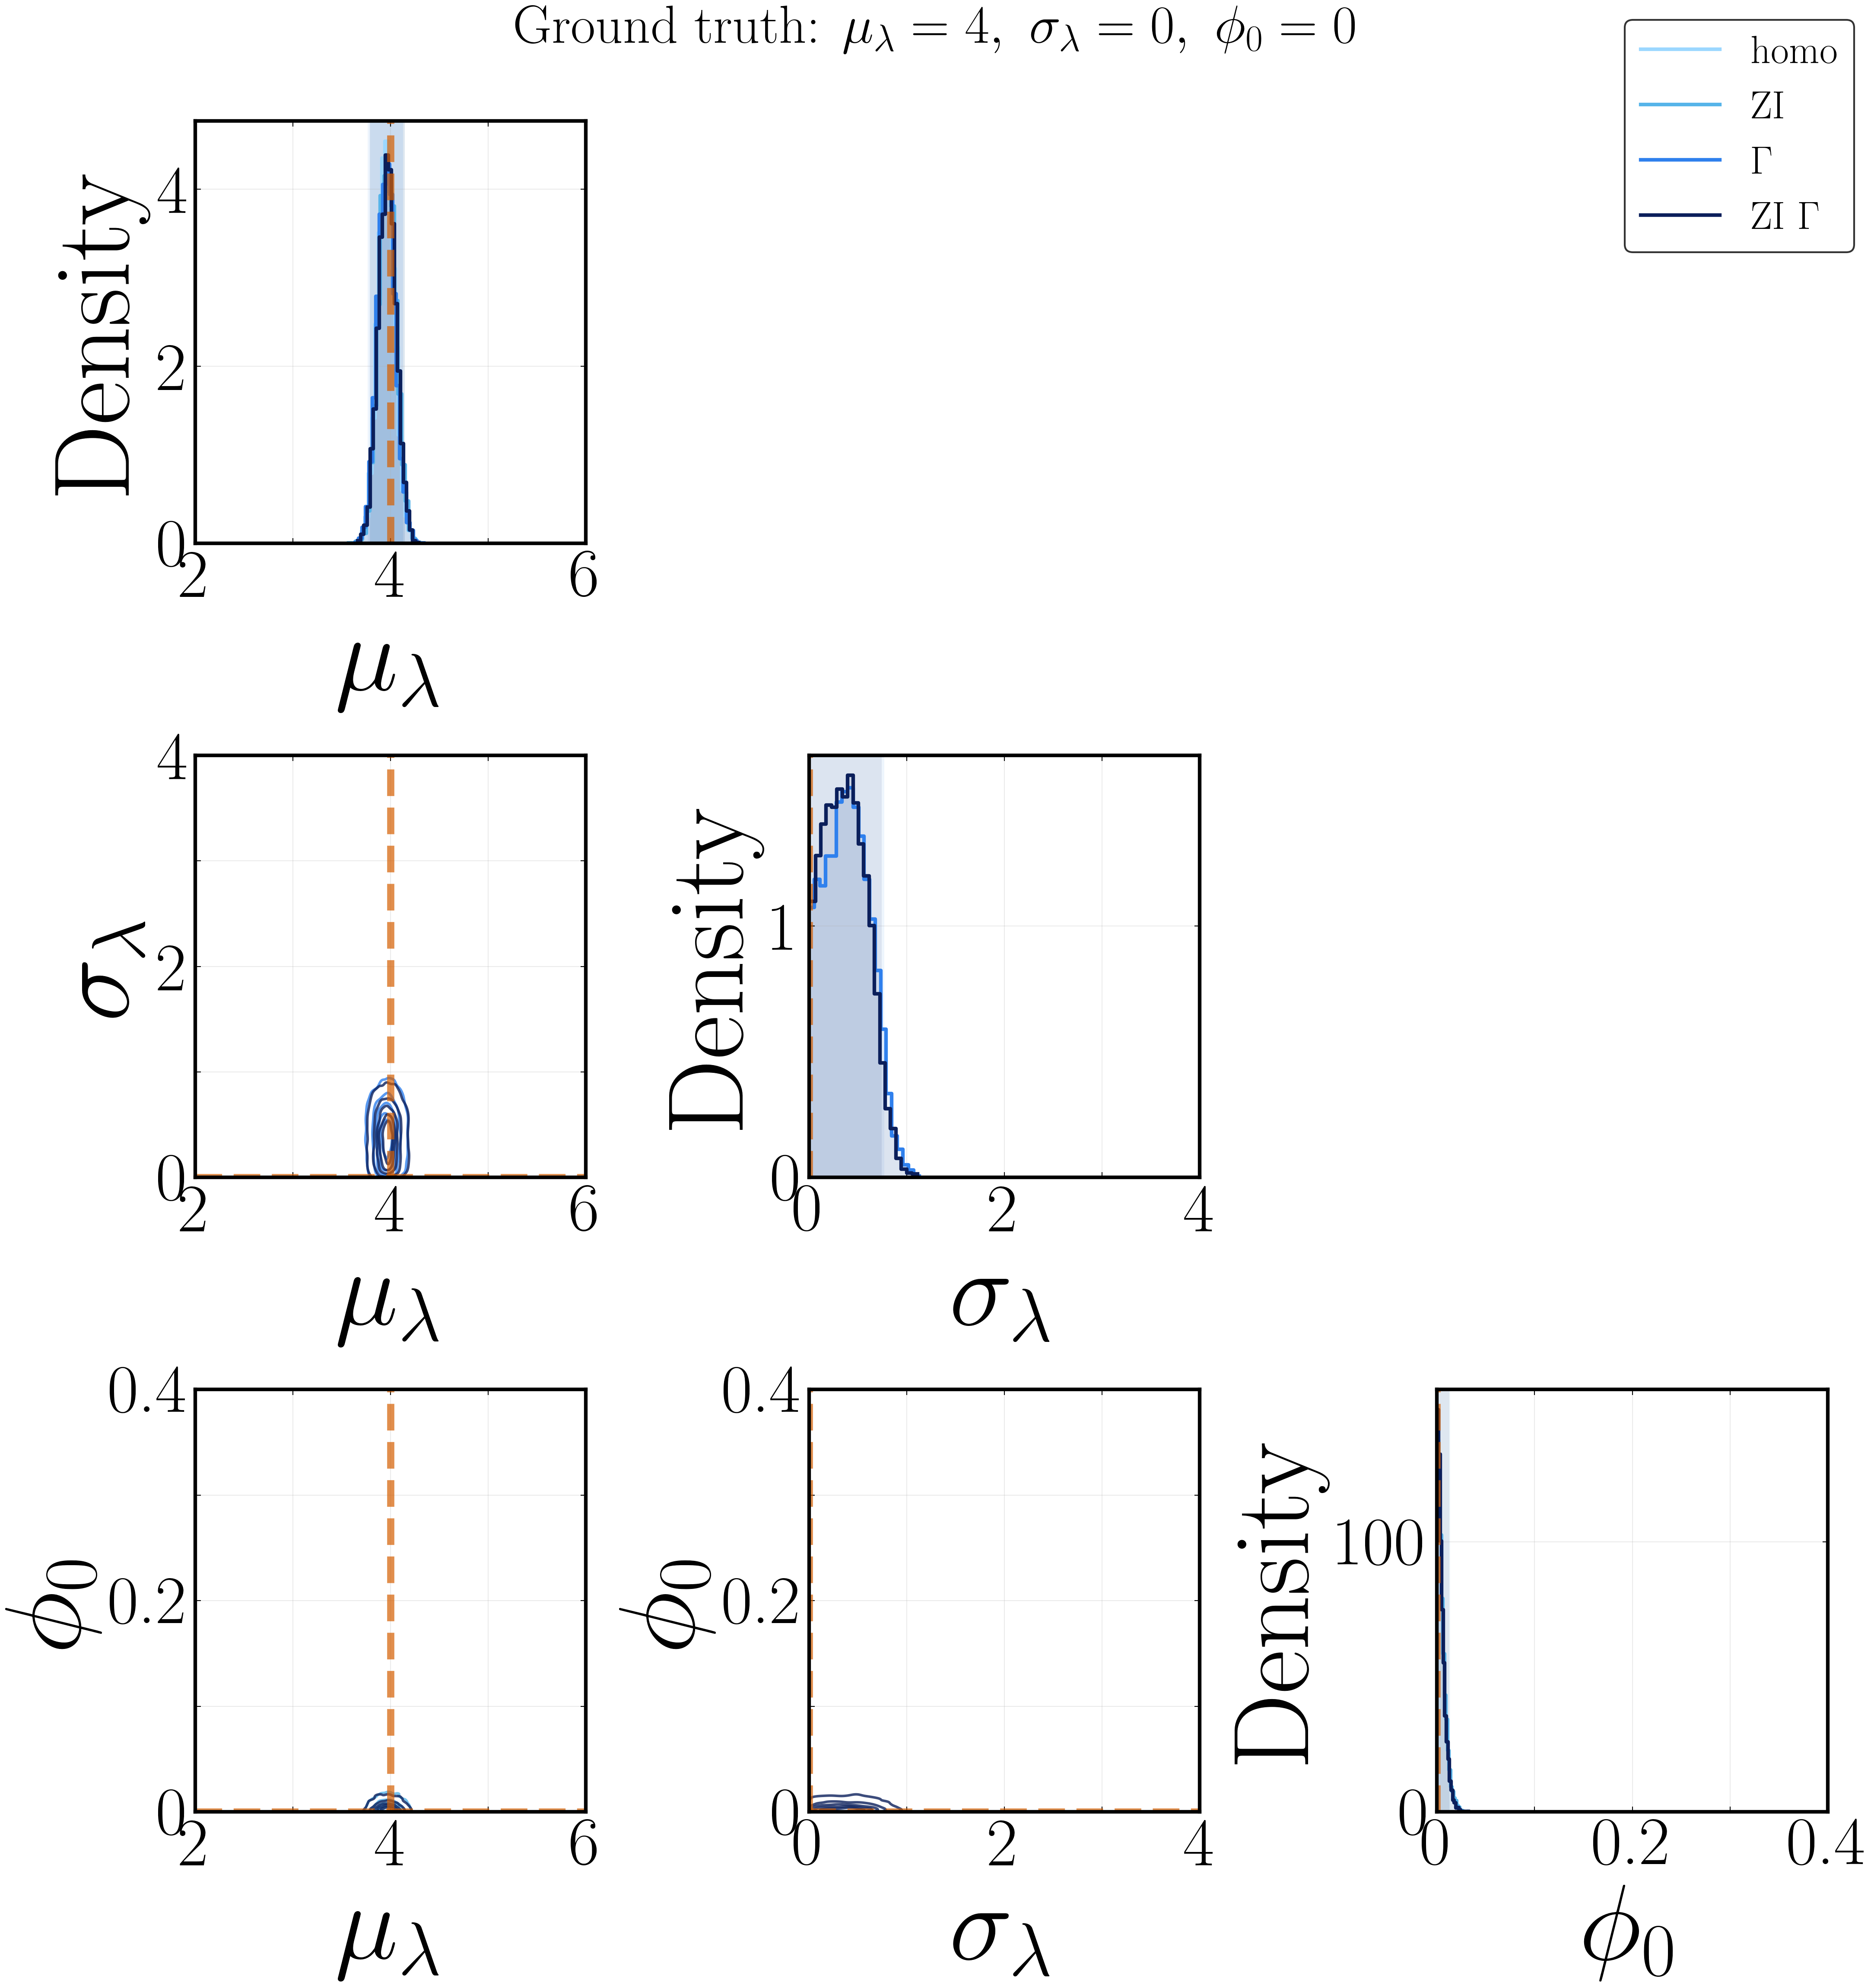

,svg
0,/Users/marsian/PhD_LifeSciRes/Orca/section_1/f...
1,/Users/marsian/PhD_LifeSciRes/Orca/section_1/f...
2,/Users/marsian/PhD_LifeSciRes/Orca/section_1/f...
3,/Users/marsian/PhD_LifeSciRes/Orca/section_1/f...


In [37]:
from pathlib import Path
from typing import Any, Dict, Optional, Sequence, Tuple

POSTERIOR_COLORS = {
    "homo":    "#9BD7FF",
    "Z2P":     "#56B4E9",
    "Dis2P":   "#2F80ED",
    "hetero3": "#0B1F5B",
}

MODEL_TO_COMMON_PARAM = {
    "homo": {
        "mu_lambda": "lambda",
    },
    "Z2P": {
        "mu_lambda": "lambda",
        "p_zero": "p_zero",
    },
    "Dis2P": {
        "mu_lambda": "mu_lambda",
        "sigma_lambda": "sigma_lambda",
    },
    "hetero3": {
        "mu_lambda": "mu_lambda",
        "sigma_lambda": "sigma_lambda",
        "p_zero": "p_zero",
    },
}




def apply_param_ticks(
    ax,
    *,
    xparam: Optional[str] = None,
    yparam: Optional[str] = None,
    param_ticks: Optional[Dict[str, Sequence[float]]] = None,
    param_ticklabels: Optional[Dict[str, Sequence[str]]] = None,
) -> None:
    if not param_ticks:
        return

    if xparam in param_ticks:
        xticks = list(param_ticks[xparam])
        ax.set_xticks(xticks)

        if param_ticklabels and xparam in param_ticklabels:
            xlabels = list(param_ticklabels[xparam])
            if len(xlabels) != len(xticks):
                raise ValueError(
                    f"{xparam}: number of tick labels ({len(xlabels)}) "
                    f"must match number of ticks ({len(xticks)})."
                )
            ax.set_xticklabels(xlabels)

    if yparam in param_ticks:
        yticks = list(param_ticks[yparam])
        ax.set_yticks(yticks)

        if param_ticklabels and yparam in param_ticklabels:
            ylabels = list(param_ticklabels[yparam])
            if len(ylabels) != len(yticks):
                raise ValueError(
                    f"{yparam}: number of tick labels ({len(ylabels)}) "
                    f"must match number of ticks ({len(yticks)})."
                )
            ax.set_yticklabels(ylabels)


def get_common_posterior_samples(
    idata: az.InferenceData,
    *,
    model_name: str,
    common_param: str,
    sample_size: int = 6000,
    seed: Optional[int] = None,
) -> np.ndarray:
    source_param = MODEL_TO_COMMON_PARAM.get(model_name, {}).get(common_param)
    if source_param is None or source_param not in idata.posterior:
        return np.array([], dtype=float)

    values = idata.posterior[source_param].stack(sample=("chain", "draw")).values.ravel()
    values = np.asarray(values, dtype=float)
    values = values[np.isfinite(values)]

    if sample_size is not None and values.size > int(sample_size):
        rng = np.random.default_rng(seed)
        values = values[rng.choice(values.size, int(sample_size), replace=False)]

    return values


def scenario_ground_truth_common(scenario: dict[str, Any]) -> dict[str, float]:
    return {
        "mu_lambda": float(scenario["mu_lambda"]),
        "sigma_lambda": float(scenario["sigma_lambda"]),
        "p_zero": float(scenario["p_zero"]),
    }


def plot_four_model_posteriors(
    scenario: dict[str, Any],
    *,
    colors: dict[str, str] = POSTERIOR_COLORS,
    parameters: Sequence[str] = COMMON_PARAMS,
    sample_size: int = 6000,
    hdi_prob: float = 0.95,
    save_dir: Path = FIGURE_ROOT,
    dpi: int = 300,
    bins: int = 20,
    param_limits: Optional[Dict[str, Tuple[float, float]]] = None,
    param_ticks: Optional[Dict[str, Sequence[float]]] = None,
    param_ticklabels: Optional[Dict[str, Sequence[str]]] = None,
) -> Path:
    gt = scenario_ground_truth_common(scenario)

    xlims = dict(PARAM_LIMITS)
    if param_limits:
        xlims.update(param_limits)

    samples: dict[str, dict[str, np.ndarray]] = {}
    for model_name in MODEL_ORDER:
        idata = posterior_data[(scenario["number"], model_name)]
        samples[model_name] = {
            param: get_common_posterior_samples(
                idata,
                model_name=model_name,
                common_param=param,
                sample_size=sample_size,
                seed=int(scenario["seed"]) + 17 * (i + 1),
            )
            for i, param in enumerate(parameters)
        }

    npar = len(parameters)
    fig, axes = plt.subplots(
        npar,
        npar,
        figsize=(4.8 * npar, 4.8 * npar),
        dpi=dpi,
        constrained_layout=True,
    )

    fig.set_constrained_layout_pads(
        w_pad=0.02,
        h_pad=0.02,
        wspace=0.03,
        hspace=0.03,
    )

    for irow, rowpar in enumerate(parameters):
        for icol, colpar in enumerate(parameters):
            ax = axes[irow, icol]
            ax.set_facecolor("white")
            ax.minorticks_off()

            for spine in ax.spines.values():
                spine.set_visible(True)
                spine.set_linewidth(2)
                spine.set_color("black")

            if icol > irow:
                ax.axis("off")
                continue

            for model_name in MODEL_ORDER:
                color = colors.get(model_name, "black")
                label = MODEL_DISPLAY.get(model_name, model_name)

                if icol == irow:
                    vals = samples[model_name][rowpar]
                    if vals.size == 0:
                        continue

                    sns.histplot(
                        vals,
                        bins=bins,
                        stat="density",
                        element="step",
                        fill=True,
                        ax=ax,
                        color=color,
                        alpha=0.08,
                        linewidth=0,
                    )

                    sns.histplot(
                        vals,
                        bins=bins,
                        stat="density",
                        element="step",
                        fill=False,
                        ax=ax,
                        color=color,
                        linewidth=2.0,
                        label=label if irow == 0 else None,
                    )

                    try:
                        lo, hi = az.hdi(vals, hdi_prob=hdi_prob)
                        ax.axvspan(float(lo), float(hi), color=color, alpha=0.08, linewidth=0)
                    except Exception:
                        pass

                else:
                    xvals = samples[model_name][colpar]
                    yvals = samples[model_name][rowpar]
                    if xvals.size == 0 or yvals.size == 0:
                        continue

                    n = min(xvals.size, yvals.size)
                    sns.kdeplot(
                        x=xvals[:n],
                        y=yvals[:n],
                        ax=ax,
                        color=color,
                        linewidths=1.4,
                        levels=6,
                        fill=False,
                        alpha=0.8,
                    )

            if icol == irow:
                ax.axvline(gt[rowpar], color="#D55E00", linestyle="--", linewidth=4, alpha=0.7)
                ax.set_xlabel(PARAM_DISPLAY.get(rowpar, rowpar), fontsize=60)
                ax.set_ylabel("Density", fontsize=60)

                if rowpar in xlims:
                    ax.set_xlim(*xlims[rowpar])

                apply_param_ticks(
                    ax,
                    xparam=rowpar,
                    param_ticks=param_ticks,
                    param_ticklabels=param_ticklabels,
                )

            else:
                ax.axvline(gt[colpar], color="#D55E00", linestyle="--", linewidth=4, alpha=0.7)
                ax.axhline(gt[rowpar], color="#D55E00", linestyle="--", linewidth=4, alpha=0.7)

                ax.set_xlabel(PARAM_DISPLAY.get(colpar, colpar), fontsize=60)
                ax.set_ylabel(PARAM_DISPLAY.get(rowpar, rowpar), fontsize=60)

                if colpar in xlims:
                    ax.set_xlim(*xlims[colpar])
                if rowpar in xlims:
                    ax.set_ylim(*xlims[rowpar])

                apply_param_ticks(
                    ax,
                    xparam=colpar,
                    yparam=rowpar,
                    param_ticks=param_ticks,
                    param_ticklabels=param_ticklabels,
                )

            ax.tick_params(axis="both", which="major", labelsize=38)
            ax.tick_params(which="minor", bottom=False, left=False)
            ax.grid(alpha=0.25)

    handles, labels = axes[0, 0].get_legend_handles_labels()
    if handles:
        fig.legend(
            handles,
            labels,
            loc="upper right",
            frameon=True,
            fontsize=22,
            edgecolor="black",
        )

    gt_label = (
        rf"$\mu_\lambda={float(scenario['mu_lambda']):g},\ "
        rf"\sigma_\lambda={float(scenario['sigma_lambda']):g},\ "
        rf"\phi_0={float(scenario['p_zero']):g}$"
    )

    fig.suptitle(
        rf"Ground truth: {gt_label}",
        fontsize=30,
        y=1.06,
    )

    save_dir = Path(save_dir)
    save_dir.mkdir(parents=True, exist_ok=True)

    out_path = (
        save_dir
        / (
            f"{scenario['number']}_"
            f"mu_lambda={float(scenario['mu_lambda']):g}_"
            f"sigma_lambda={float(scenario['sigma_lambda']):g}_"
            f"phi0={float(scenario['p_zero']):g}.svg"
        )
    )

    fig.savefig(
        out_path,
        format="svg",
        bbox_inches="tight",
        pad_inches=0.2,
        transparent=True,
    )
    plt.show()

    return out_path


posterior_comparison_svg_paths = []

PARAM_LIMITS = {
    "mu_lambda": (2, 6),
    "sigma_lambda": (0, 4),
    "p_zero": (0, 0.4),
}

for scenario in SCENARIOS:
    posterior_comparison_svg_paths.append(
        plot_four_model_posteriors(
            scenario,
            colors=POSTERIOR_COLORS,
            bins=20,
            param_limits=PARAM_LIMITS,
            param_ticks={
                "mu_lambda": [2, 3, 4, 5, 6],
                "sigma_lambda": [0, 1, 2, 3, 4],
                "p_zero": [0, 0.1, 0.2,0.3, 0.4],
            },
            param_ticklabels={
                "mu_lambda": ["2", "", "4", "", "6"],
                "sigma_lambda": ["0", "",  "2", "",  "4"],
                "p_zero": ["0", "", "0.2", "", "0.4"],
            },
        )
    )

pd.DataFrame({"svg": [str(path) for path in posterior_comparison_svg_paths]})

**Bayes Factor**

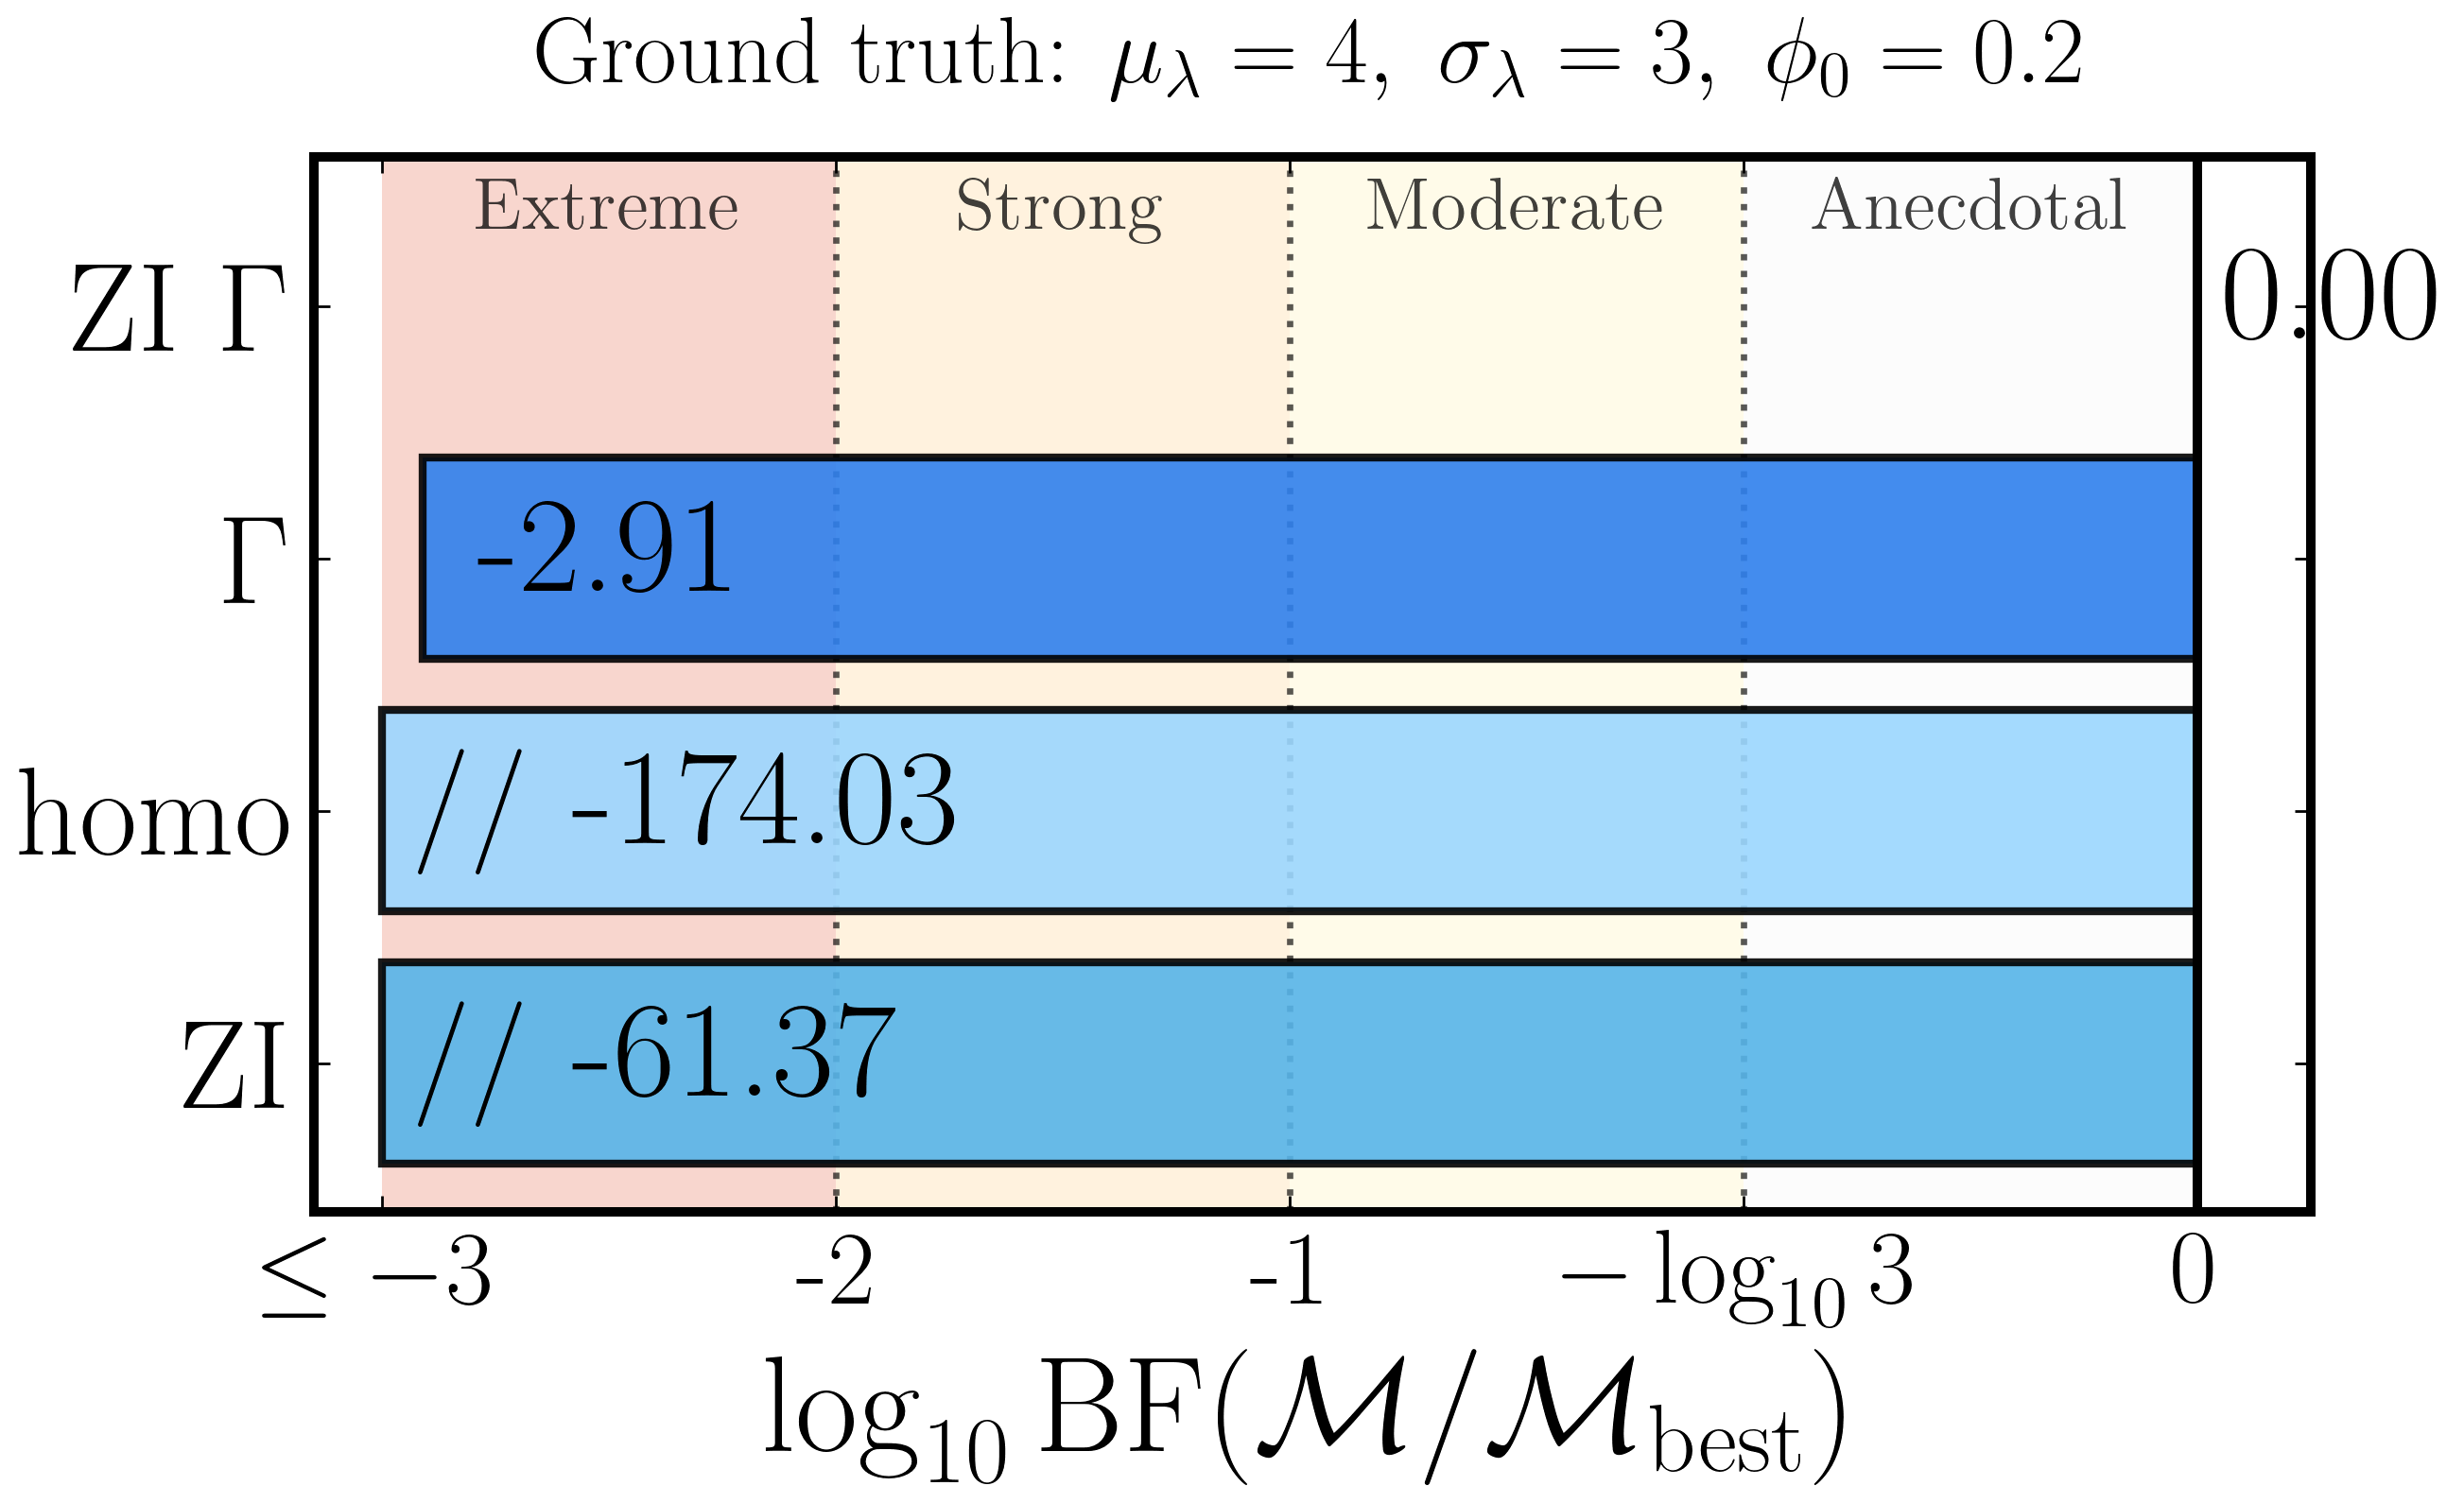

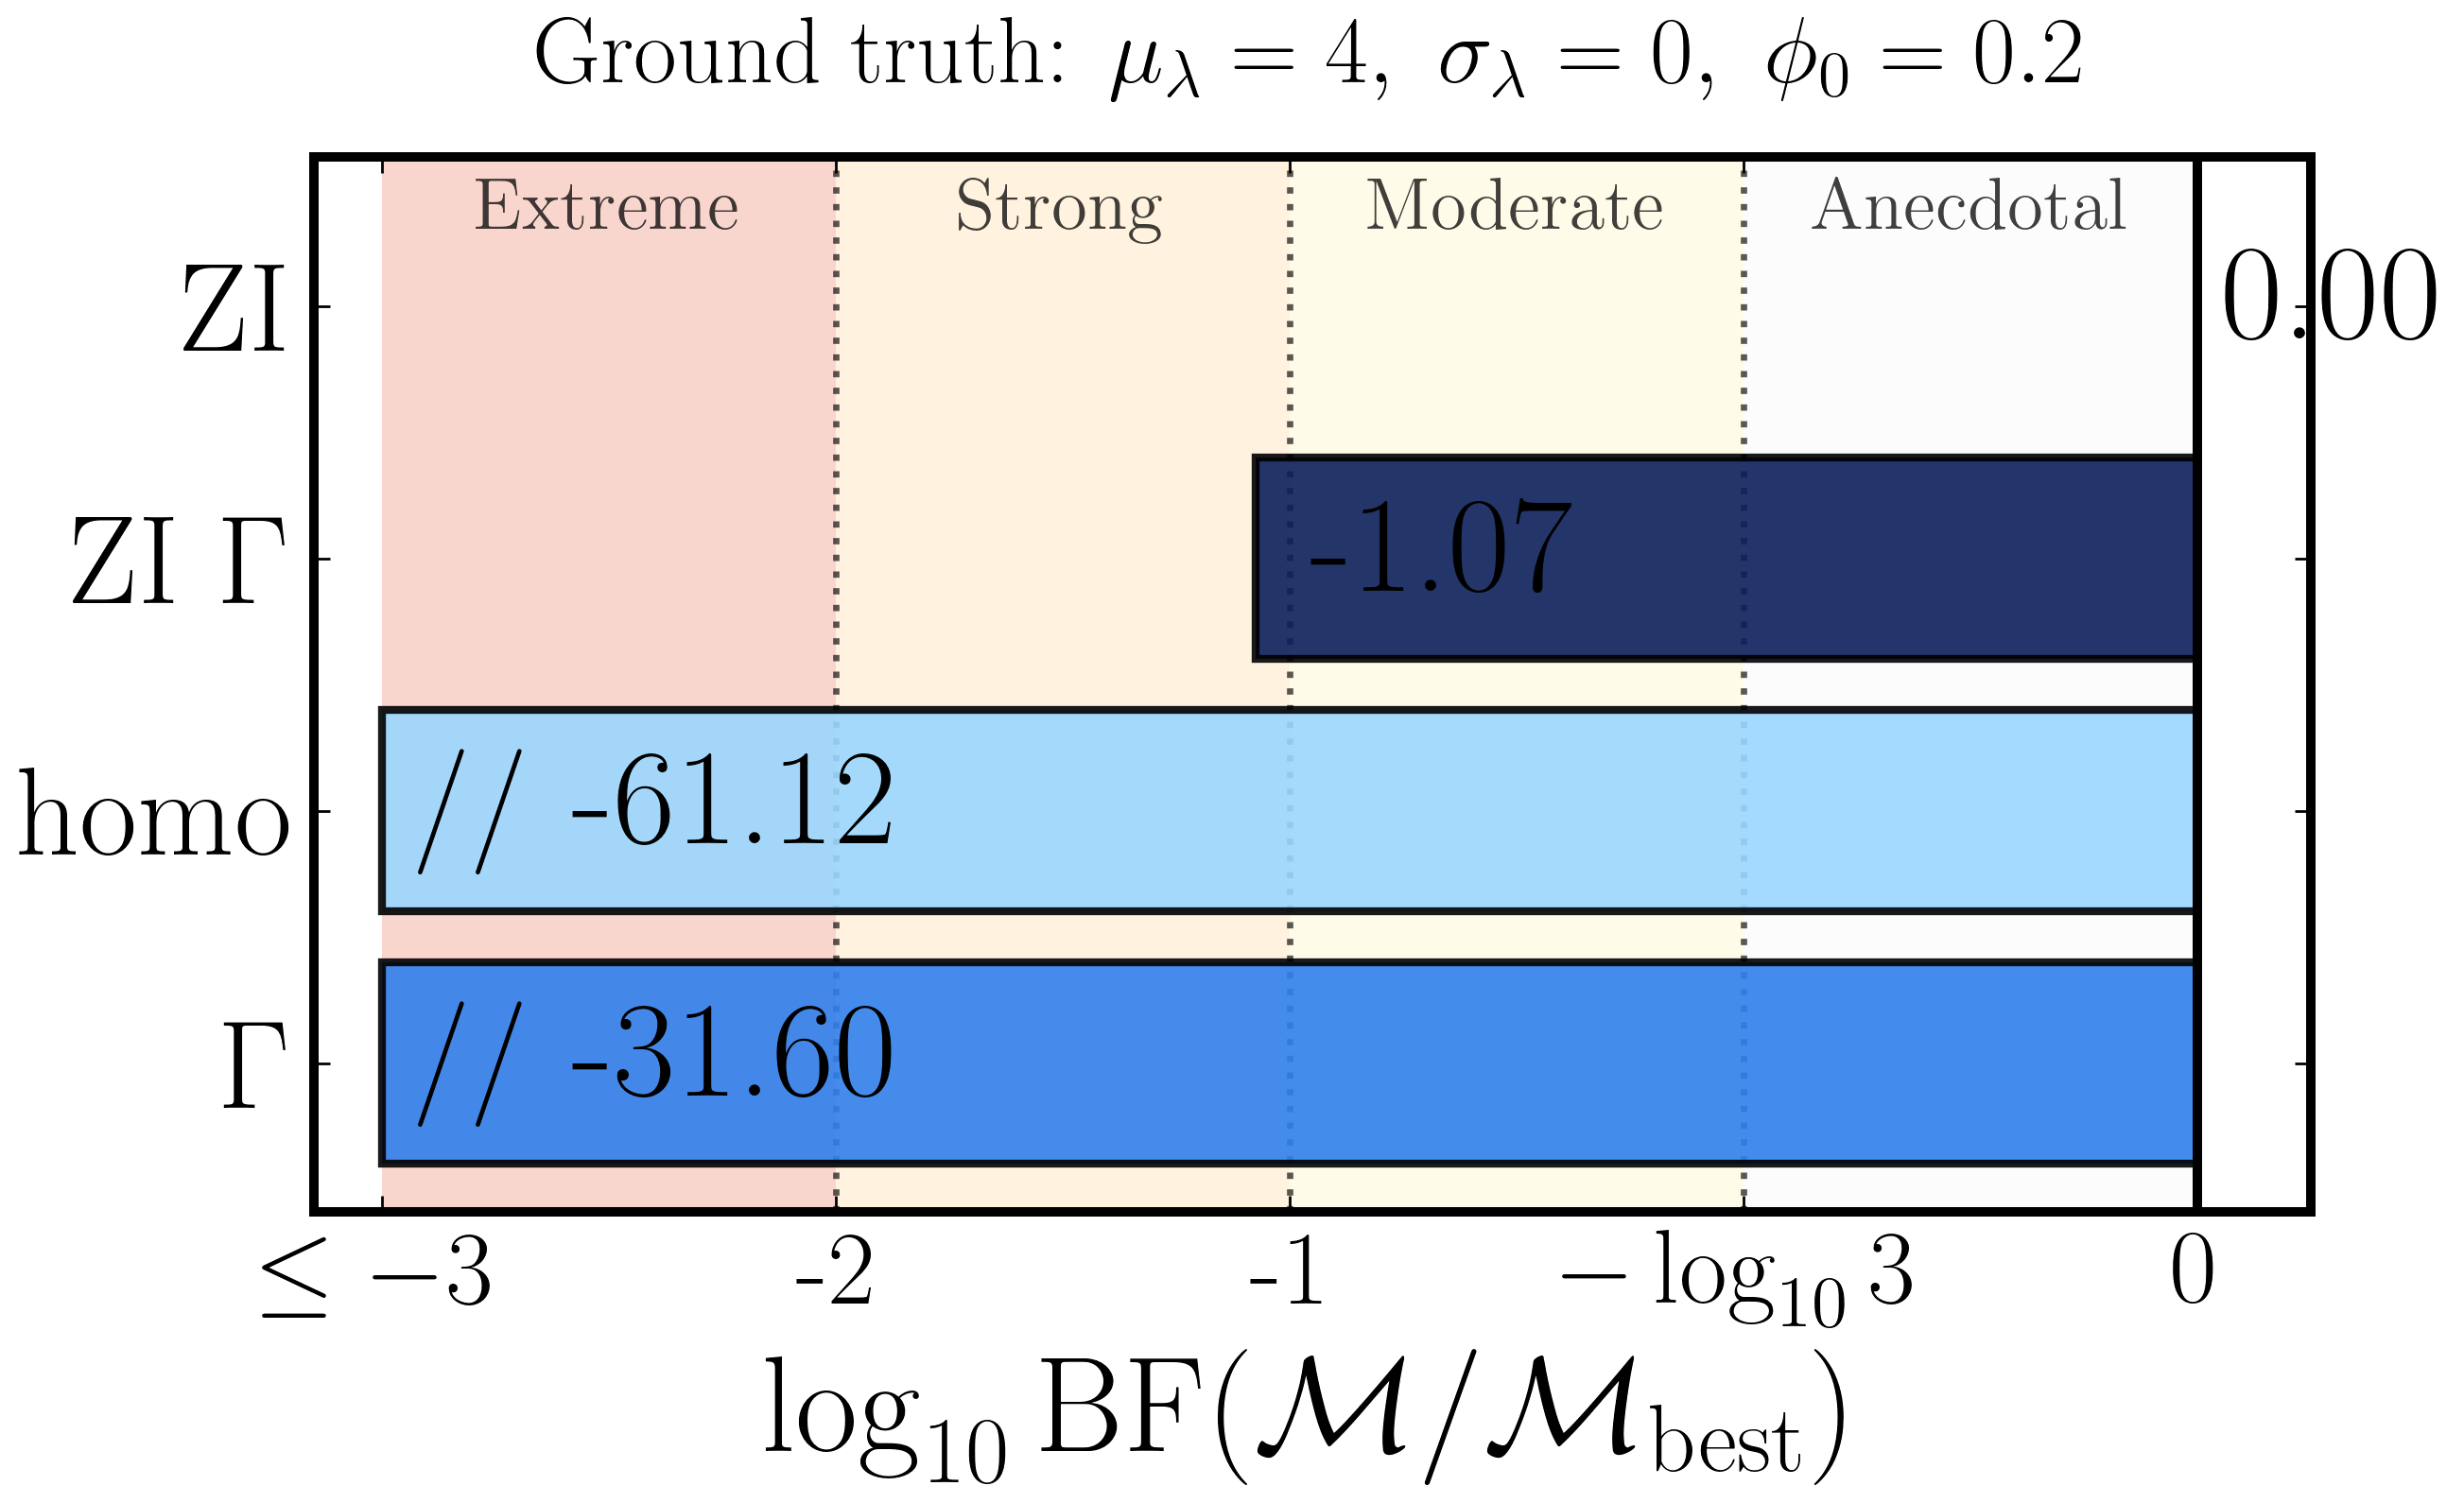

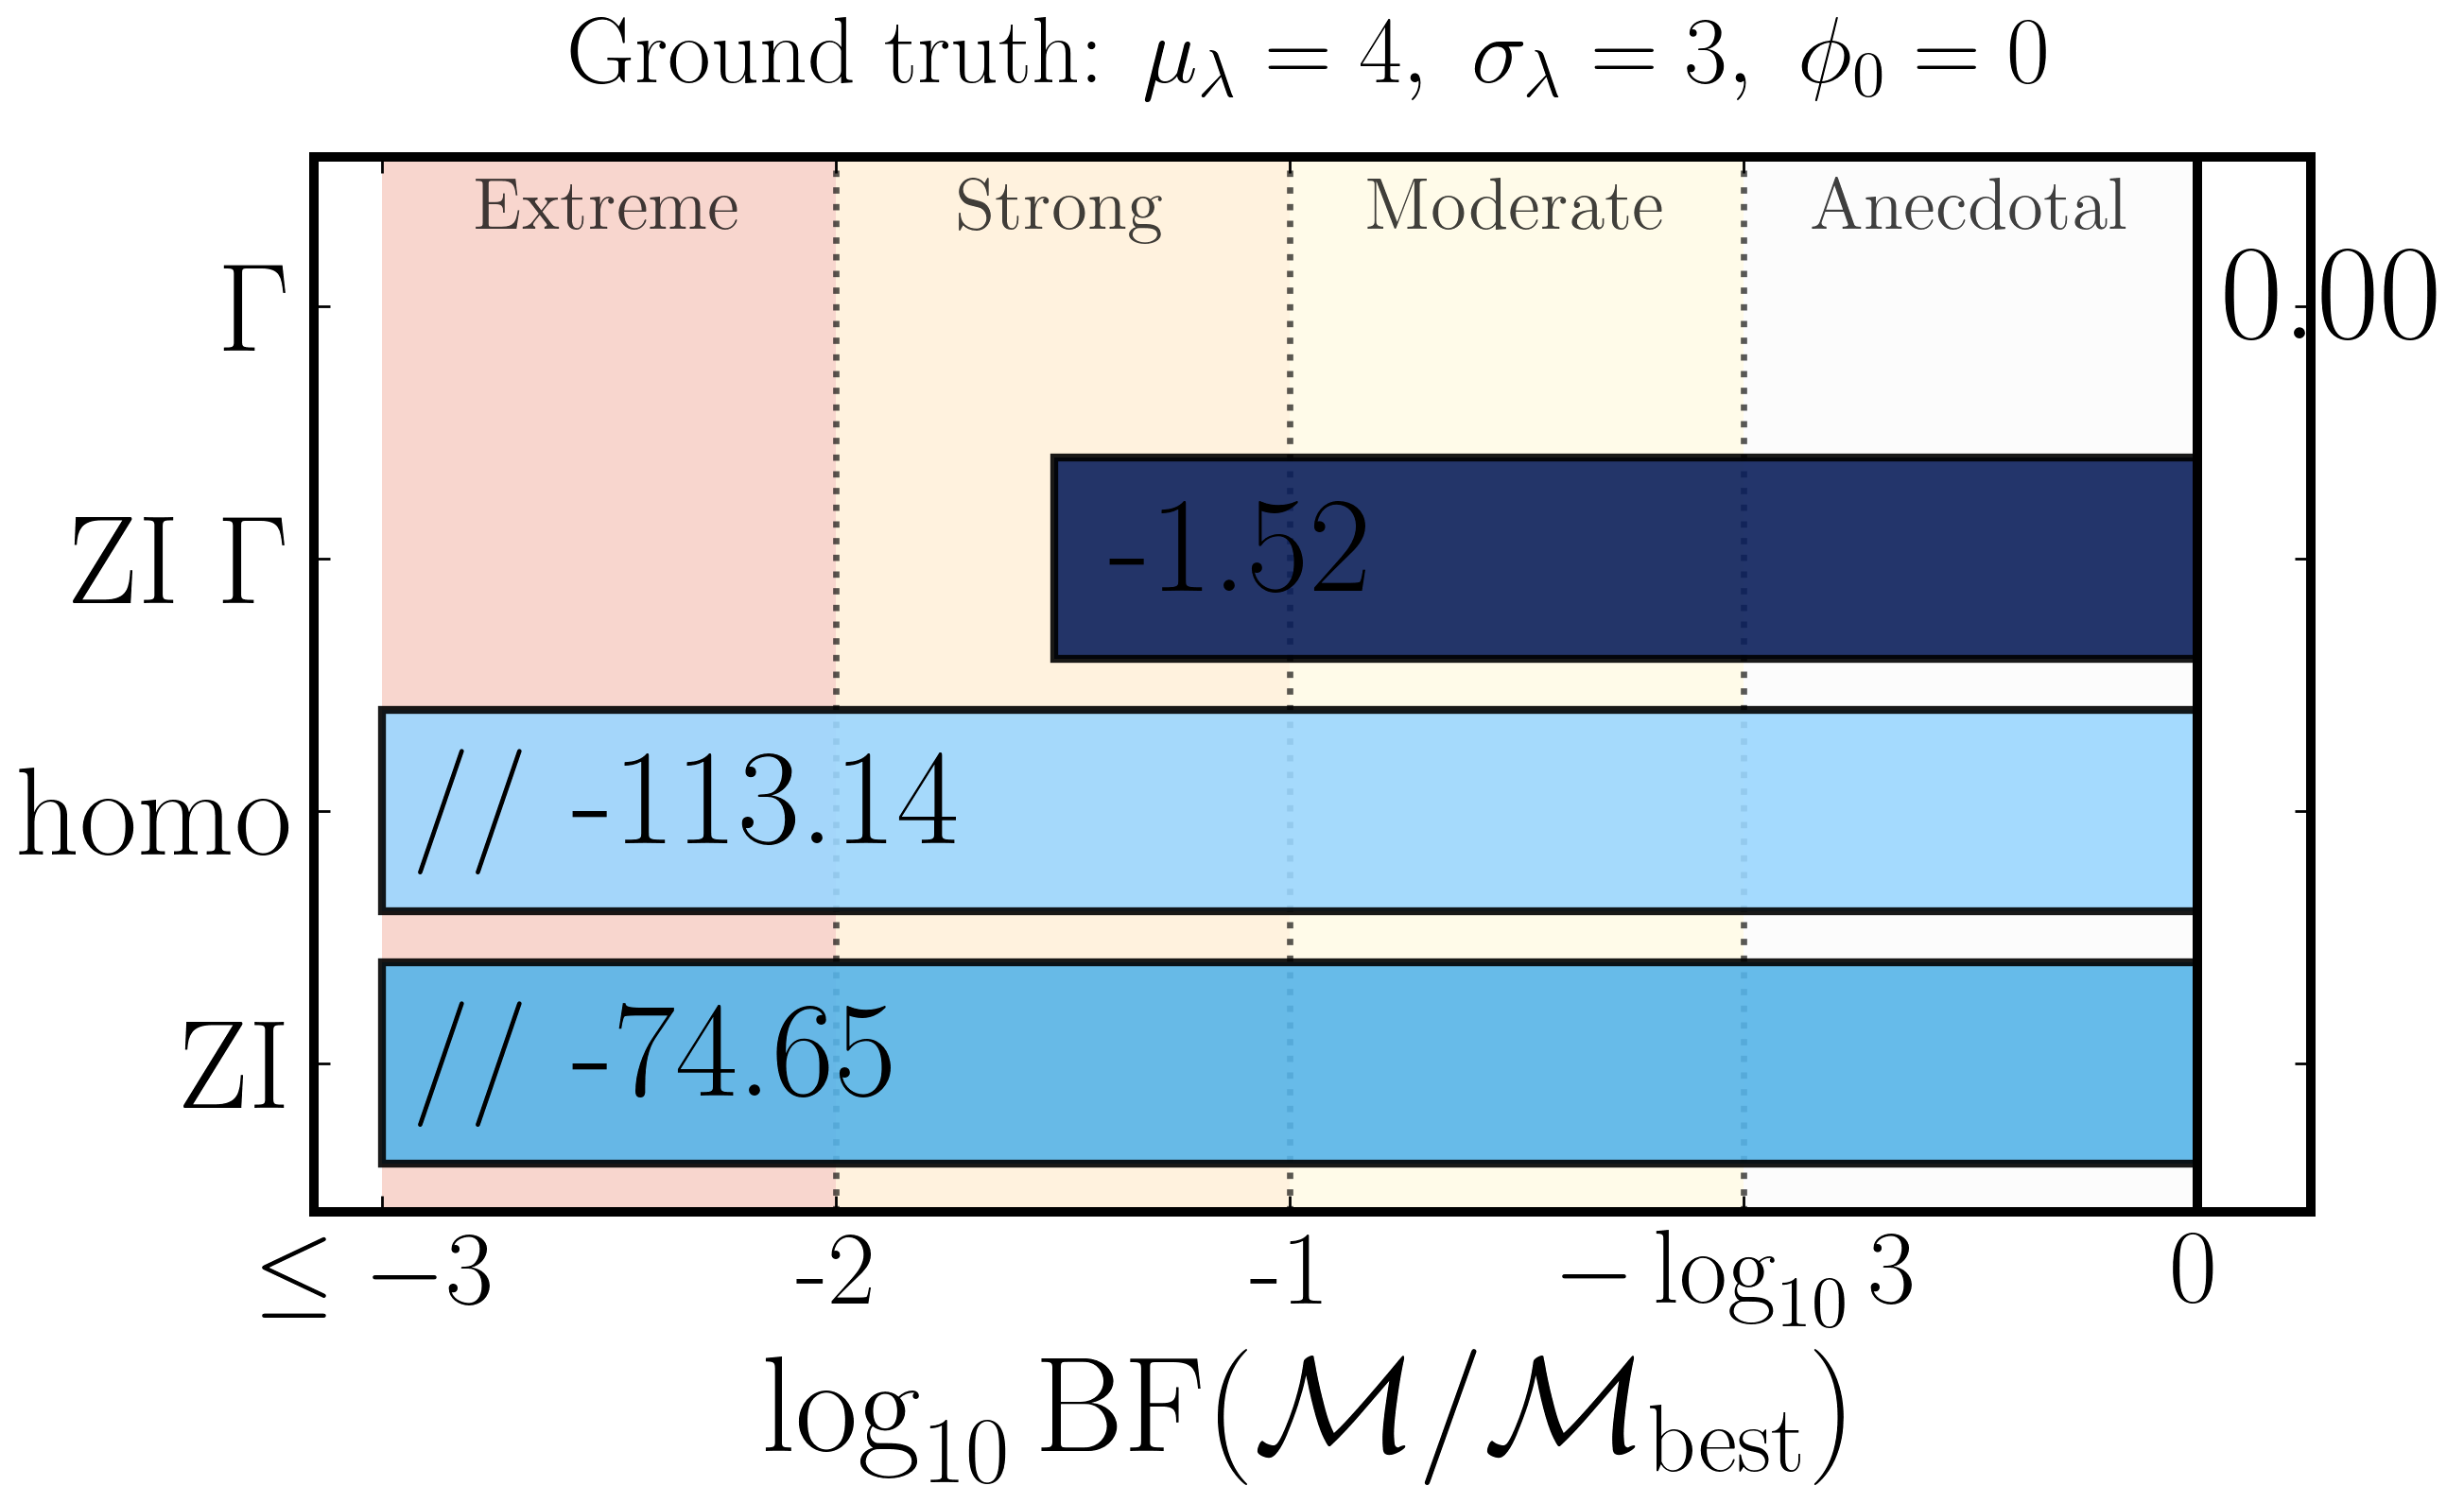

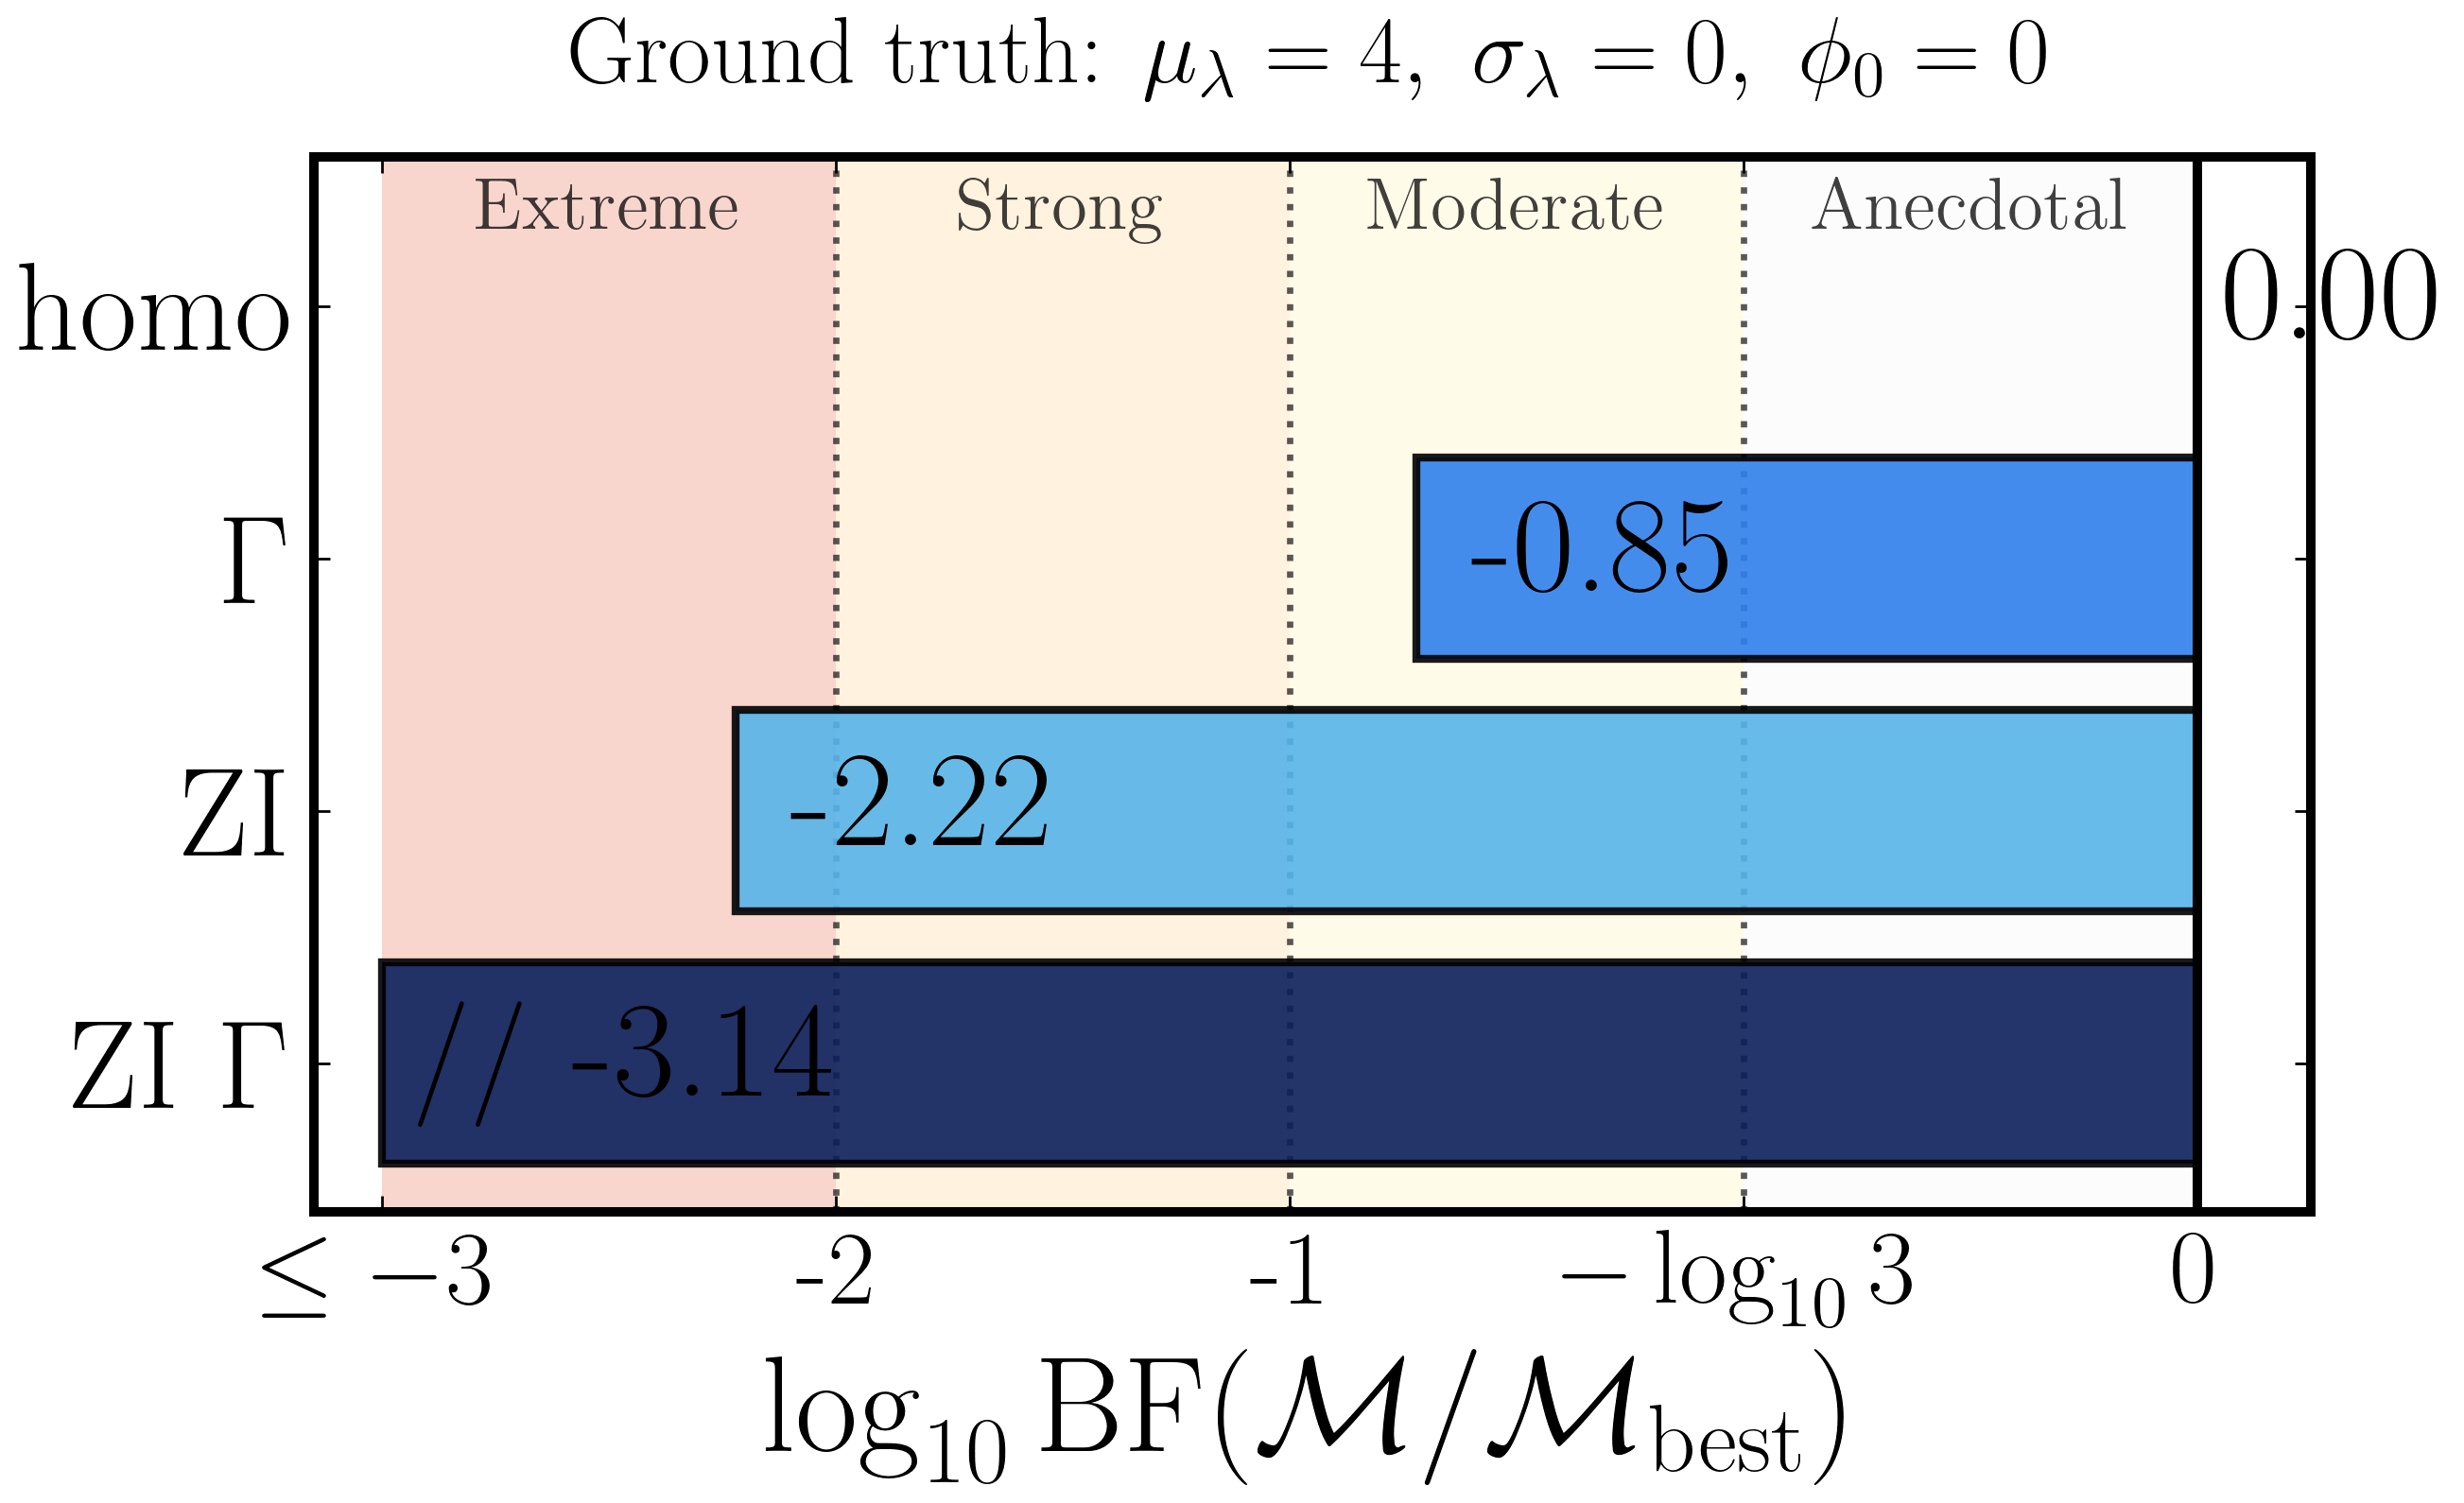

,svg
0,/Users/marsian/PhD_LifeSciRes/Orca/section_1/f...
1,/Users/marsian/PhD_LifeSciRes/Orca/section_1/f...
2,/Users/marsian/PhD_LifeSciRes/Orca/section_1/f...
3,/Users/marsian/PhD_LifeSciRes/Orca/section_1/f...


In [38]:
def _to_banded_bf_axis(
    log10_bf_model_vs_best,
    *,
    clip_log10_evidence: float = 3.0,
):
    """
    Convert raw log10 BF(M / M_best) onto an equal-width visual axis.

    Display bands:
        0 to -1:   anecdotal, BF_best/model < 3
        -1 to -2:   moderate,   3 to 10
        -2 to -3:   strong,     10 to 100
        -3 to -4:   extreme,    >100

    Values beyond clip_log10_evidence are clipped visually.
    The original values should still be printed as text labels.
    """
    value = np.asarray(log10_bf_model_vs_best, dtype=float)
    evidence = np.maximum(-value, 0.0)

    bf3 = np.log10(3.0)
    bf10 = 1.0
    bf100 = 2.0
    clip_log10_evidence = max(float(clip_log10_evidence), bf100 + 1e-6)

    display = np.zeros_like(evidence, dtype=float)

    mask = evidence <= bf3
    display[mask] = evidence[mask] / bf3

    mask = (evidence > bf3) & (evidence <= bf10)
    display[mask] = 1.0 + (evidence[mask] - bf3) / (bf10 - bf3)

    mask = (evidence > bf10) & (evidence <= bf100)
    display[mask] = 2.0 + (evidence[mask] - bf10) / (bf100 - bf10)

    mask = evidence > bf100
    display[mask] = 3.0 + np.minimum(
        (evidence[mask] - bf100) / (clip_log10_evidence - bf100),
        1.0,
    )

    return -display


def plot_bayes_factor(
    scenario: dict[str, Any],
    *,
    save_dir: Path = FIGURE_ROOT,
    dpi: int = 400,
    colors: dict[str, str] = POSTERIOR_COLORS,
    band_colors: dict[str, str] | None = None,
    band_alpha: float = 0.28,
    clip_log10_evidence: float = 3.0,
) -> Path:
    if band_colors is None:
        band_colors = {
            "anecdotal": "#F7F7F7",
            "moderate": "#FFF3B0",
            "strong": "#FFD28A",
            "extreme": "#E76F51",
        }

    scenario_id = scenario["number"]

    scen_logml = (
        logml_df[logml_df["scenario"] == scenario_id]
        .copy()
        .sort_values("logml", ascending=False)
    )

    best_model = str(scen_logml.iloc[0]["model"])
    best_logml = float(scen_logml.iloc[0]["logml"])

    scen_logml["log10_BF_model_vs_best"] = (
        scen_logml["logml"] - best_logml
    ) / np.log(10.0)

    scen_logml["x_plot"] = _to_banded_bf_axis(
        scen_logml["log10_BF_model_vs_best"].to_numpy(),
        clip_log10_evidence=clip_log10_evidence,
    )

    scen_logml["is_clipped"] = (
        -scen_logml["log10_BF_model_vs_best"] > clip_log10_evidence
    )

    scen_logml["model_label"] = (
        scen_logml["model"]
        .map(MODEL_DISPLAY)
        .fillna(scen_logml["model"])
    )

    scen_logml = scen_logml.sort_values("x_plot", ascending=True)

    bar_colors = [
        "#000000" if model == best_model else colors.get(model, "black")
        for model in scen_logml["model"]
    ]

    fig, ax = plt.subplots(figsize=(8.8, 4.5), dpi=dpi)

    xleft = -4.15
    xright = 0.25
    ax.set_xlim(xleft, xright)

    bands = [
        ("extreme", -4.0, -3.0),
        ("strong", -3.0, -2.0),
        ("moderate", -2.0, -1.0),
        ("anecdotal", -1.0, 0.0),
    ]

    for label, left, right in bands:
        ax.axvspan(
            left,
            right,
            color=band_colors.get(label, "white"),
            alpha=band_alpha,
            linewidth=0,
            zorder=0,
        )
        ax.text(
            (left + right) / 2,
            0.98,
            label.capitalize(),
            transform=ax.get_xaxis_transform(),
            ha="center",
            va="top",
            fontsize=14,
            color="black",
            alpha=0.75,
            zorder=1,
        )

    for threshold in [-1.0, -2.0, -3.0]:
        ax.axvline(
            threshold,
            color="black",
            linestyle=":",
            linewidth=1.2,
            alpha=0.65,
            zorder=2,
        )

    bars = ax.barh(
        scen_logml["model_label"],
        scen_logml["x_plot"],
        color=bar_colors,
        alpha=0.9,
        edgecolor="black",
        linewidth=1.5,
        zorder=3,
    )

    ax.axvline(0, color="black", linewidth=1.8, zorder=4)

    for bar, raw_value, x_plot, is_clipped in zip(
        bars,
        scen_logml["log10_BF_model_vs_best"],
        scen_logml["x_plot"],
        scen_logml["is_clipped"],
    ):
        y = bar.get_y() + bar.get_height() / 2

        if is_clipped:
            ax.text(
                x_plot + 0.08,
                y,
                "//",
                va="center",
                ha="left",
                fontsize=24,
                color="black",
                zorder=5,
            )
            text_x = x_plot + 0.42
        elif x_plot < -0.3:
            text_x = x_plot + 0.12
        else:
            text_x = 0.06

        ax.text(
            text_x,
            y,
            f"{raw_value:.2f}",
            va="center",
            ha="left",
            fontsize=26,
            color="black",
            zorder=5,
        )

    ax.set_xticks([0, -1, -2, -3, -4])
    ax.set_xticklabels(
        [
            "0",
            r"$-\log_{10}3$",
            "-1",
            "-2",
            rf"$\leq -{clip_log10_evidence:g}$",
        ]
    )

    ax.set_xlabel(
        r"$\log_{10}\mathrm{BF}(\mathcal{M}/\mathcal{M}_{\mathrm{best}})$",
        fontsize=26,
    )

    ax.tick_params(axis="x", which="major", labelsize=20)
    ax.tick_params(axis="y", which="major", labelsize=24)
    ax.minorticks_off()
    ax.grid(False)

    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_linewidth(1.8)
        spine.set_color("black")

    gt_label = (
        rf"$\mu_\lambda={float(scenario['mu_lambda']):g},\ "
        rf"\sigma_\lambda={float(scenario['sigma_lambda']):g},\ "
        rf"\phi_0={float(scenario['p_zero']):g}$"
    )

    ax.set_title(
        rf"Ground truth: {gt_label}",
        fontsize=18,
        pad=14,
    )

    fig.subplots_adjust(left=0.30, bottom=0.26)

    save_dir = Path(save_dir)
    save_dir.mkdir(parents=True, exist_ok=True)

    out_path = (
        save_dir
        / (
            f"{scenario['number']}_bayes_factor_model_vs_best_banded_"
            f"mu_lambda={float(scenario['mu_lambda']):g}_"
            f"sigma_lambda={float(scenario['sigma_lambda']):g}_"
            f"phi0={float(scenario['p_zero']):g}.svg"
        )
    )

    fig.savefig(
        out_path,
        format="svg",
        bbox_inches="tight",
        pad_inches=0.2,
        transparent=True,
    )
    plt.show()

    return out_path


bayes_factor_model_vs_best_svg_paths = []

for scenario in SCENARIOS:
    bayes_factor_model_vs_best_svg_paths.append(
        plot_bayes_factor(
            scenario,
            save_dir=FIGURE_ROOT,
            colors=POSTERIOR_COLORS,
            band_colors={
                "anecdotal": "#F7F7F7",
                "moderate": "#FFF3B0",
                "strong": "#FFD28A",
                "extreme": "#E76F51",
            },
            band_alpha=0.28,
            clip_log10_evidence=3.0,
        )
    )

pd.DataFrame({"svg": [str(path) for path in bayes_factor_model_vs_best_svg_paths]})